<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [1]:
!pip install -q transformers datasets accelerate

In [2]:
from datasets import load_dataset, ClassLabel
from collections import Counter

ds = load_dataset("csv", data_files="/kaggle/input/datasets/zvictor12/mathematical-tasks/data_problems_translated.xlsx - Sheet1.csv")
ds = ds["train"]
ds = ds.remove_columns(ds.column_names[0])

topics = ds.unique("topic")
display(topics)
NUM_CLASSES = len(topics)
display(Counter(ds["topic"]))

ds = ds.cast_column("topic", ClassLabel(names=topics))

Generating train split: 0 examples [00:00, ? examples/s]

['number_theory',
 'polynoms',
 'combinatorics',
 'graphs',
 'geometry',
 'invariant',
 'dirichlet']

Counter({'number_theory': 2396,
         'polynoms': 426,
         'combinatorics': 1020,
         'graphs': 384,
         'geometry': 371,
         'invariant': 235,
         'dirichlet': 441})

Casting the dataset:   0%|          | 0/5273 [00:00<?, ? examples/s]

In [3]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5273 [00:00<?, ? examples/s]

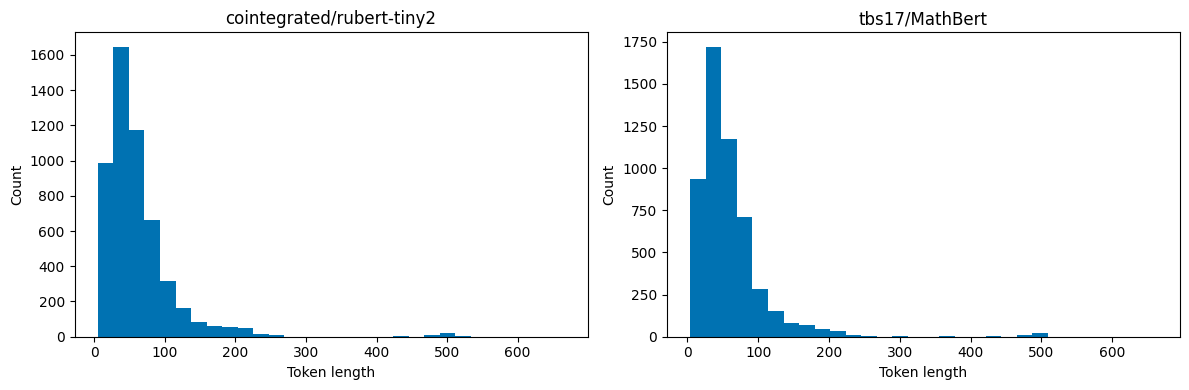

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-colorblind")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model_name in zip(axes, ["cointegrated/rubert-tiny2", "tbs17/MathBert"]):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    lengths = ds.map(lambda x: {"len": len(tokenizer(x["problem_text"])["input_ids"])})
    ax.hist(lengths["len"], bins=30)
    ax.set_title(model_name)
    ax.set_xlabel("Token length")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [5]:
num1, info = AutoModelForSequenceClassification.from_pretrained("cointegrated/rubert-tiny2", output_loading_info=True)
print(info["missing_keys"], info["unexpected_keys"])
num1

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

{'classifier.weight', 'classifier.bias'} {'cls.predictions.bias', 'bert.embeddings.position_ids', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight'}


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(83828, 312, padding_idx=0)
      (position_embeddings): Embedding(2048, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, 

In [6]:
num2, info = AutoModelForSequenceClassification.from_pretrained("tbs17/MathBert", output_loading_info=True)
print(info["missing_keys"], info["unexpected_keys"])
num2

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: tbs17/MathBert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

{'classifier.weight', 'classifier.bias'} {'cls.predictions.bias', 'cls.predictions.decoder.bias', 'bert.embeddings.position_ids', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight'}


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [22]:
from typing import Union
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch import nn

class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module]):
        super().__init__()
        model = (
            AutoModelForSequenceClassification.from_pretrained(
                base_transformer_model, attn_implementation="eager"
            )
            if isinstance(base_transformer_model, str)
            else base_transformer_model
        )
        self.backbone = model.bert
        hidden = model.classifier.in_features
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(hidden, NUM_CLASSES),
        )

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.head(outputs.pooler_output)
        return {"logits": logits}

In [8]:
ds = ds.train_test_split(test_size=0.1, seed=42, stratify_by_column="topic")

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [9]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [10]:
def prepare_data(model_name, max_length=256):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    ds_tokenized = ds.map(
        lambda x: tokenizer(x["problem_text"], truncation=True, max_length=max_length),
        batched=True,
    )
    ds_tokenized = ds_tokenized.rename_column("topic", "labels")
    ds_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    return ds_tokenized, tokenizer

In [11]:
from transformers import Trainer, TrainingArguments, TrainerCallback
from IPython.display import display
from tqdm.auto import tqdm

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {"f1": f1_score(labels, preds, average="macro")}

class LivePlotCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.eval_f1s = []
        self.steps = []
        self.eval_steps = []
        self.display_handle = None

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        if "loss" in logs:
            self.train_losses.append(logs["loss"])
            self.steps.append(state.global_step)
        if "eval_f1" in logs:
            self.eval_losses.append(logs.get("eval_loss", 0))
            self.eval_f1s.append(logs["eval_f1"])
            self.eval_steps.append(state.global_step)

            epoch = state.epoch or 0.0
            train_loss = self.train_losses[-1] if self.train_losses else 0
            eval_loss = self.eval_losses[-1]
            eval_f1 = self.eval_f1s[-1]
            tqdm.write(
                f"Epoch: {epoch:.1f} | Train loss: {train_loss:.4f} | "
                f"Eval loss: {eval_loss:.4f} | Eval F1: {eval_f1:.4f}"
            )

            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].plot(self.steps, self.train_losses, label="train")
            axes[0].plot(self.eval_steps, self.eval_losses, label="eval")
            axes[0].set_xlabel("Steps")
            axes[0].set_ylabel("Loss")
            axes[0].legend()

            axes[1].plot(self.eval_steps, self.eval_f1s, label="eval f1")
            axes[1].set_xlabel("Steps")
            axes[1].set_ylabel("F1 (macro)")
            axes[1].legend()
            plt.tight_layout()

            if self.display_handle is None:
                self.display_handle = display(fig, display_id=True)
            else:
                self.display_handle.update(fig)
            plt.close(fig)

In [12]:
import copy
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import DataCollatorWithPadding


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        logits = model(**inputs)["logits"]
        loss = F.cross_entropy(logits, labels, weight=self.class_weights.to(logits.device))
        return (loss, {"logits": logits}) if return_outputs else loss


def train_transformer(
    transformer_model,
    ds_tokenized,
    tokenizer,
    run_name,
    freeze_backbone=False,
    learning_rate=None,
    num_epochs=10,
):
    model = copy.deepcopy(transformer_model)
    for param in model.parameters():
        param.data = param.data.contiguous()
    for buf in model.buffers():
        buf.data = buf.data.contiguous()

    if freeze_backbone:
        freeze_backbone_function(model)
        if learning_rate is None:
            learning_rate = 1e-3
    else:
        if learning_rate is None:
            learning_rate = 2e-5

    train_labels = np.array(ds_tokenized["train"]["labels"])
    classes = np.arange(NUM_CLASSES)
    cw = compute_class_weight("balanced", classes=classes, y=train_labels)
    class_weights = torch.tensor(cw, dtype=torch.float)

    args = TrainingArguments(
        output_dir=f"./results/{run_name}",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        eval_strategy="steps",
        eval_steps=50,
        logging_steps=50,
        save_strategy="steps",
        save_steps=50,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1",
        greater_is_better=True,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_ratio=0.1,
        lr_scheduler_type="linear",
        fp16=torch.cuda.is_available(),
        report_to="none",
        disable_tqdm=False,
        logging_first_step=True,
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=ds_tokenized["train"],
        eval_dataset=ds_tokenized["test"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[LivePlotCallback()],
        class_weights=class_weights,
    )
    trainer.train()
    trainer.save_model(f"./results/{run_name}/best")
    return model

In [13]:
import warnings
warnings.filterwarnings("ignore")

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

Map:   0%|          | 0/4745 [00:00<?, ? examples/s]

Map:   0%|          | 0/528 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Step,Training Loss,Validation Loss,F1
50,1.864864,1.716019,0.281275
100,1.495292,1.446716,0.371852
150,1.317146,1.370866,0.373859
200,1.247922,1.321510,0.421108
250,1.191629,1.305846,0.411498
300,1.138960,1.268793,0.421393
350,1.120140,1.267420,0.432702
400,1.124291,1.271968,0.427966
450,1.101454,1.258714,0.437143
500,1.072682,1.260553,0.440316


Epoch: 0.7 | Train loss: 1.8649 | Eval loss: 1.7160 | Eval F1: 0.2813


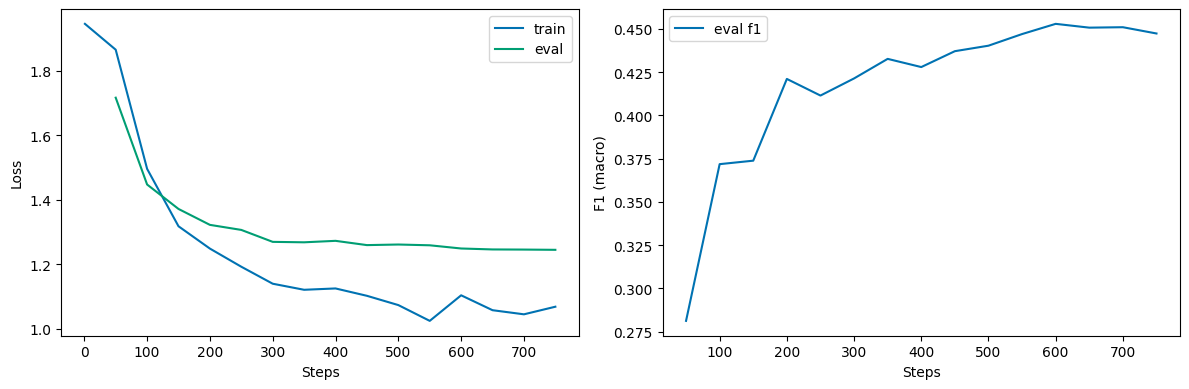

Epoch: 1.3 | Train loss: 1.4953 | Eval loss: 1.4467 | Eval F1: 0.3719
Epoch: 2.0 | Train loss: 1.3171 | Eval loss: 1.3709 | Eval F1: 0.3739
Epoch: 2.7 | Train loss: 1.2479 | Eval loss: 1.3215 | Eval F1: 0.4211
Epoch: 3.3 | Train loss: 1.1916 | Eval loss: 1.3058 | Eval F1: 0.4115
Epoch: 4.0 | Train loss: 1.1390 | Eval loss: 1.2688 | Eval F1: 0.4214
Epoch: 4.7 | Train loss: 1.1201 | Eval loss: 1.2674 | Eval F1: 0.4327
Epoch: 5.3 | Train loss: 1.1243 | Eval loss: 1.2720 | Eval F1: 0.4280
Epoch: 6.0 | Train loss: 1.1015 | Eval loss: 1.2587 | Eval F1: 0.4371
Epoch: 6.7 | Train loss: 1.0727 | Eval loss: 1.2606 | Eval F1: 0.4403
Epoch: 7.3 | Train loss: 1.0237 | Eval loss: 1.2582 | Eval F1: 0.4470
Epoch: 8.0 | Train loss: 1.1030 | Eval loss: 1.2482 | Eval F1: 0.4529
Epoch: 8.7 | Train loss: 1.0568 | Eval loss: 1.2453 | Eval F1: 0.4507
Epoch: 9.3 | Train loss: 1.0440 | Eval loss: 1.2449 | Eval F1: 0.4510
Epoch: 10.0 | Train loss: 1.0676 | Eval loss: 1.2441 | Eval F1: 0.4474


In [14]:
ds_tokenized_rubert, tok_rubert = prepare_data("cointegrated/rubert-tiny2")

rubert_tiny_transformer_model = TransformerClassificationModel("cointegrated/rubert-tiny2")
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    rubert_tiny_transformer_model, ds_tokenized_rubert, tok_rubert,
    run_name="rubert_tiny_frozen", freeze_backbone=True,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,F1
50,1.939126,1.916515,0.211671
100,1.843106,1.721701,0.295644
150,1.591905,1.513905,0.319052
200,1.429789,1.425490,0.347503
250,1.328900,1.378416,0.370598
300,1.254311,1.343967,0.378719
350,1.213436,1.304407,0.383777
400,1.179218,1.289567,0.389660
450,1.155547,1.265563,0.399468
500,1.108153,1.248966,0.403954


Epoch: 0.7 | Train loss: 1.9391 | Eval loss: 1.9165 | Eval F1: 0.2117


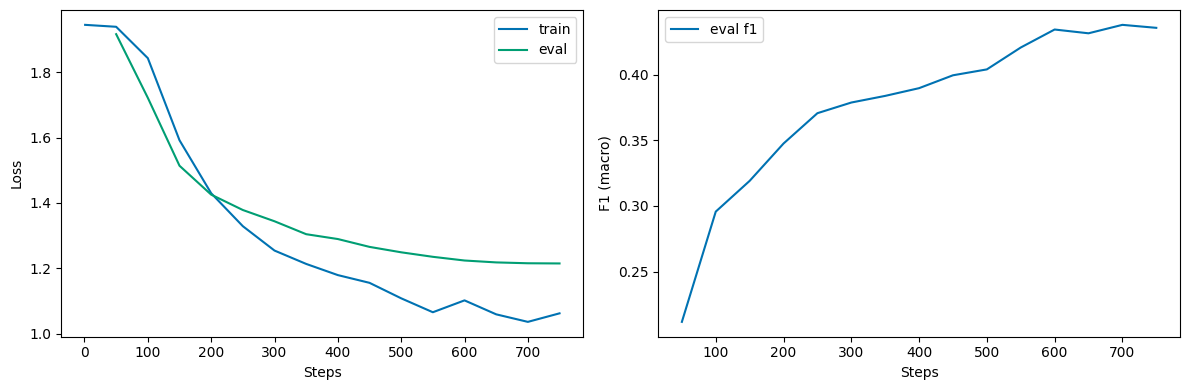

Epoch: 1.3 | Train loss: 1.8431 | Eval loss: 1.7217 | Eval F1: 0.2956
Epoch: 2.0 | Train loss: 1.5919 | Eval loss: 1.5139 | Eval F1: 0.3191
Epoch: 2.7 | Train loss: 1.4298 | Eval loss: 1.4255 | Eval F1: 0.3475
Epoch: 3.3 | Train loss: 1.3289 | Eval loss: 1.3784 | Eval F1: 0.3706
Epoch: 4.0 | Train loss: 1.2543 | Eval loss: 1.3440 | Eval F1: 0.3787
Epoch: 4.7 | Train loss: 1.2134 | Eval loss: 1.3044 | Eval F1: 0.3838
Epoch: 5.3 | Train loss: 1.1792 | Eval loss: 1.2896 | Eval F1: 0.3897
Epoch: 6.0 | Train loss: 1.1555 | Eval loss: 1.2656 | Eval F1: 0.3995
Epoch: 6.7 | Train loss: 1.1082 | Eval loss: 1.2490 | Eval F1: 0.4040
Epoch: 7.3 | Train loss: 1.0656 | Eval loss: 1.2352 | Eval F1: 0.4206
Epoch: 8.0 | Train loss: 1.1019 | Eval loss: 1.2239 | Eval F1: 0.4343
Epoch: 8.7 | Train loss: 1.0591 | Eval loss: 1.2181 | Eval F1: 0.4314
Epoch: 9.3 | Train loss: 1.0361 | Eval loss: 1.2154 | Eval F1: 0.4379
Epoch: 10.0 | Train loss: 1.0622 | Eval loss: 1.2149 | Eval F1: 0.4356


In [15]:
rubert_tiny_full_finetuned = train_transformer(
    rubert_tiny_transformer_model, ds_tokenized_rubert, tok_rubert,
    run_name="rubert_tiny_full", freeze_backbone=False,
)

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

Map:   0%|          | 0/4745 [00:00<?, ? examples/s]

Map:   0%|          | 0/528 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: tbs17/MathBert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

Step,Training Loss,Validation Loss,F1
50,1.777825,1.512371,0.326808
100,1.465401,1.392156,0.326899
150,1.405001,1.373807,0.373217
200,1.345479,1.397523,0.377409
250,1.295768,1.381690,0.456494
300,1.237562,1.354896,0.455282
350,1.245688,1.353689,0.375317
400,1.259744,1.299391,0.430711
450,1.192992,1.277449,0.438857
500,1.168398,1.257893,0.454936


Epoch: 0.7 | Train loss: 1.7778 | Eval loss: 1.5124 | Eval F1: 0.3268


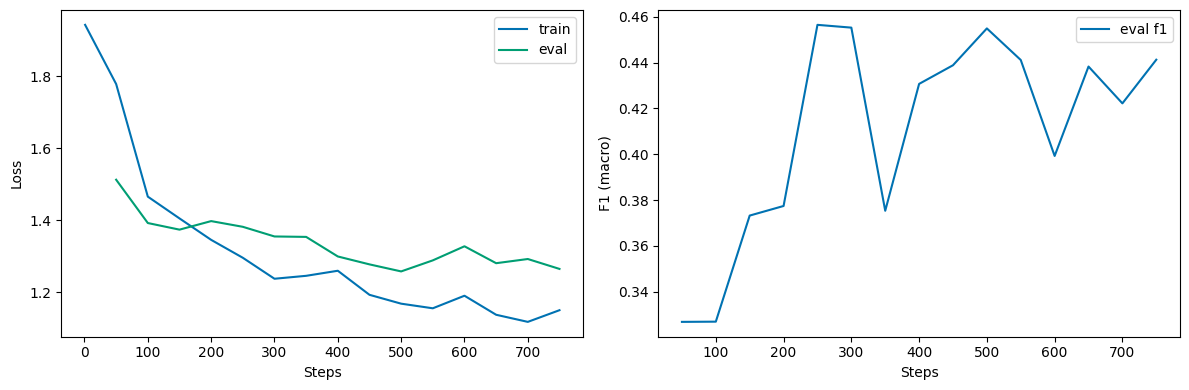

Epoch: 1.3 | Train loss: 1.4654 | Eval loss: 1.3922 | Eval F1: 0.3269
Epoch: 2.0 | Train loss: 1.4050 | Eval loss: 1.3738 | Eval F1: 0.3732
Epoch: 2.7 | Train loss: 1.3455 | Eval loss: 1.3975 | Eval F1: 0.3774
Epoch: 3.3 | Train loss: 1.2958 | Eval loss: 1.3817 | Eval F1: 0.4565
Epoch: 4.0 | Train loss: 1.2376 | Eval loss: 1.3549 | Eval F1: 0.4553
Epoch: 4.7 | Train loss: 1.2457 | Eval loss: 1.3537 | Eval F1: 0.3753
Epoch: 5.3 | Train loss: 1.2597 | Eval loss: 1.2994 | Eval F1: 0.4307
Epoch: 6.0 | Train loss: 1.1930 | Eval loss: 1.2774 | Eval F1: 0.4389
Epoch: 6.7 | Train loss: 1.1684 | Eval loss: 1.2579 | Eval F1: 0.4549
Epoch: 7.3 | Train loss: 1.1556 | Eval loss: 1.2886 | Eval F1: 0.4412
Epoch: 8.0 | Train loss: 1.1904 | Eval loss: 1.3276 | Eval F1: 0.3993
Epoch: 8.7 | Train loss: 1.1376 | Eval loss: 1.2807 | Eval F1: 0.4383
Epoch: 9.3 | Train loss: 1.1179 | Eval loss: 1.2923 | Eval F1: 0.4222
Epoch: 10.0 | Train loss: 1.1503 | Eval loss: 1.2648 | Eval F1: 0.4413


In [16]:
ds_tokenized_mathbert, tok_mathbert = prepare_data("tbs17/MathBert")

mathbert_transformer_model = TransformerClassificationModel("tbs17/MathBert")
mathbert_finetuned_with_freezed_backbone = train_transformer(
    mathbert_transformer_model, ds_tokenized_mathbert, tok_mathbert,
    run_name="mathbert_frozen", freeze_backbone=True,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,F1
50,1.851445,1.606766,0.279351
100,1.337657,1.281403,0.413290
150,1.122878,1.174063,0.453004
200,0.942886,1.101695,0.494150
250,0.829038,1.110517,0.493580
300,0.732479,1.079572,0.529695
350,0.618614,1.154712,0.536124
400,0.582760,1.181665,0.542959
450,0.554005,1.172084,0.518505
500,0.478956,1.239141,0.534244


Epoch: 0.7 | Train loss: 1.8514 | Eval loss: 1.6068 | Eval F1: 0.2794


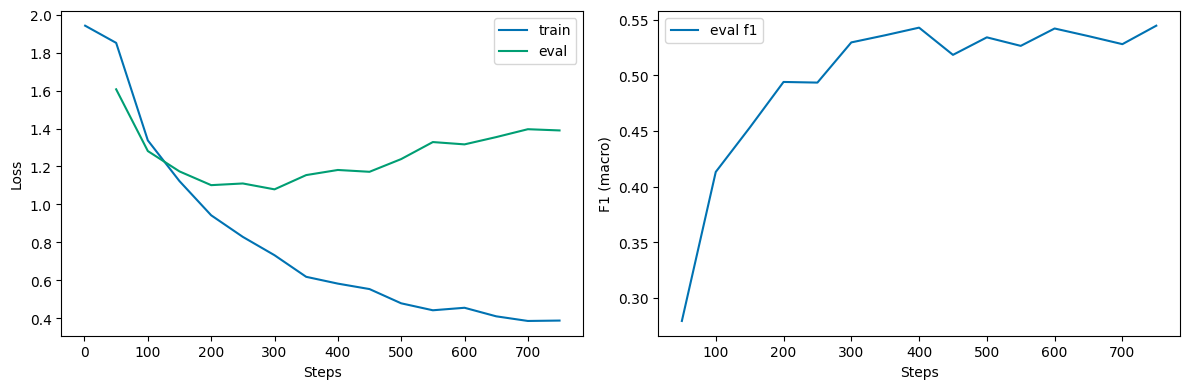

Epoch: 1.3 | Train loss: 1.3377 | Eval loss: 1.2814 | Eval F1: 0.4133
Epoch: 2.0 | Train loss: 1.1229 | Eval loss: 1.1741 | Eval F1: 0.4530
Epoch: 2.7 | Train loss: 0.9429 | Eval loss: 1.1017 | Eval F1: 0.4941
Epoch: 3.3 | Train loss: 0.8290 | Eval loss: 1.1105 | Eval F1: 0.4936
Epoch: 4.0 | Train loss: 0.7325 | Eval loss: 1.0796 | Eval F1: 0.5297
Epoch: 4.7 | Train loss: 0.6186 | Eval loss: 1.1547 | Eval F1: 0.5361
Epoch: 5.3 | Train loss: 0.5828 | Eval loss: 1.1817 | Eval F1: 0.5430
Epoch: 6.0 | Train loss: 0.5540 | Eval loss: 1.1721 | Eval F1: 0.5185
Epoch: 6.7 | Train loss: 0.4790 | Eval loss: 1.2391 | Eval F1: 0.5342
Epoch: 7.3 | Train loss: 0.4423 | Eval loss: 1.3288 | Eval F1: 0.5266
Epoch: 8.0 | Train loss: 0.4555 | Eval loss: 1.3166 | Eval F1: 0.5422
Epoch: 8.7 | Train loss: 0.4104 | Eval loss: 1.3549 | Eval F1: 0.5353
Epoch: 9.3 | Train loss: 0.3860 | Eval loss: 1.3965 | Eval F1: 0.5281
Epoch: 10.0 | Train loss: 0.3880 | Eval loss: 1.3900 | Eval F1: 0.5447


In [17]:
mathbert_full_finetuned = train_transformer(
    mathbert_transformer_model, ds_tokenized_mathbert, tok_mathbert,
    run_name="mathbert_full", freeze_backbone=False,
)

In [23]:
import os
from safetensors.torch import load_file as safe_load

def load_best_checkpoint(run_name, base_model_name):
    model = TransformerClassificationModel(base_model_name)
    ckpt_dir = f"./results/{run_name}/best"
    st_path = os.path.join(ckpt_dir, "model.safetensors")
    bin_path = os.path.join(ckpt_dir, "pytorch_model.bin")
    state = safe_load(st_path) if os.path.exists(st_path) else torch.load(bin_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model

In [24]:
rubert_tiny_finetuned_with_freezed_backbone = load_best_checkpoint("rubert_tiny_frozen", "cointegrated/rubert-tiny2")
rubert_tiny_full_finetuned                  = load_best_checkpoint("rubert_tiny_full",   "cointegrated/rubert-tiny2")
mathbert_finetuned_with_freezed_backbone    = load_best_checkpoint("mathbert_frozen",    "tbs17/MathBert")
mathbert_full_finetuned                     = load_best_checkpoint("mathbert_full",      "tbs17/MathBert")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: tbs17/MathBert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: tbs17/MathBert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [44]:
from typing import List
import seaborn as sns

def draw_first_layer_attention_maps(attention_head_ids: List, text: str, model: TransformerClassificationModel, modelName: str, title: str = None):
    tokenizer = AutoTokenizer.from_pretrained(modelName)
    inputs = tokenizer(text, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    model.eval()
    with torch.no_grad():
        outputs = model.backbone(**inputs, output_attentions=True)

    first_layer_attention = outputs.attentions[0][0]

    fig, axes = plt.subplots(1, len(attention_head_ids), figsize=(9 * len(attention_head_ids), 8))
    if len(attention_head_ids) == 1:
        axes = [axes]

    for ax, head_id in zip(axes, attention_head_ids):
        attn = first_layer_attention[head_id].cpu().numpy()
        gr = sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, ax=ax, cmap="viridis")
        gr.tick_params(labelsize=15)
        ax.set_title(f"Head {head_id}", fontsize=12)
        ax.tick_params(axis="x", rotation=90)

    fig.suptitle(title or modelName, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: tbs17/MathBert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

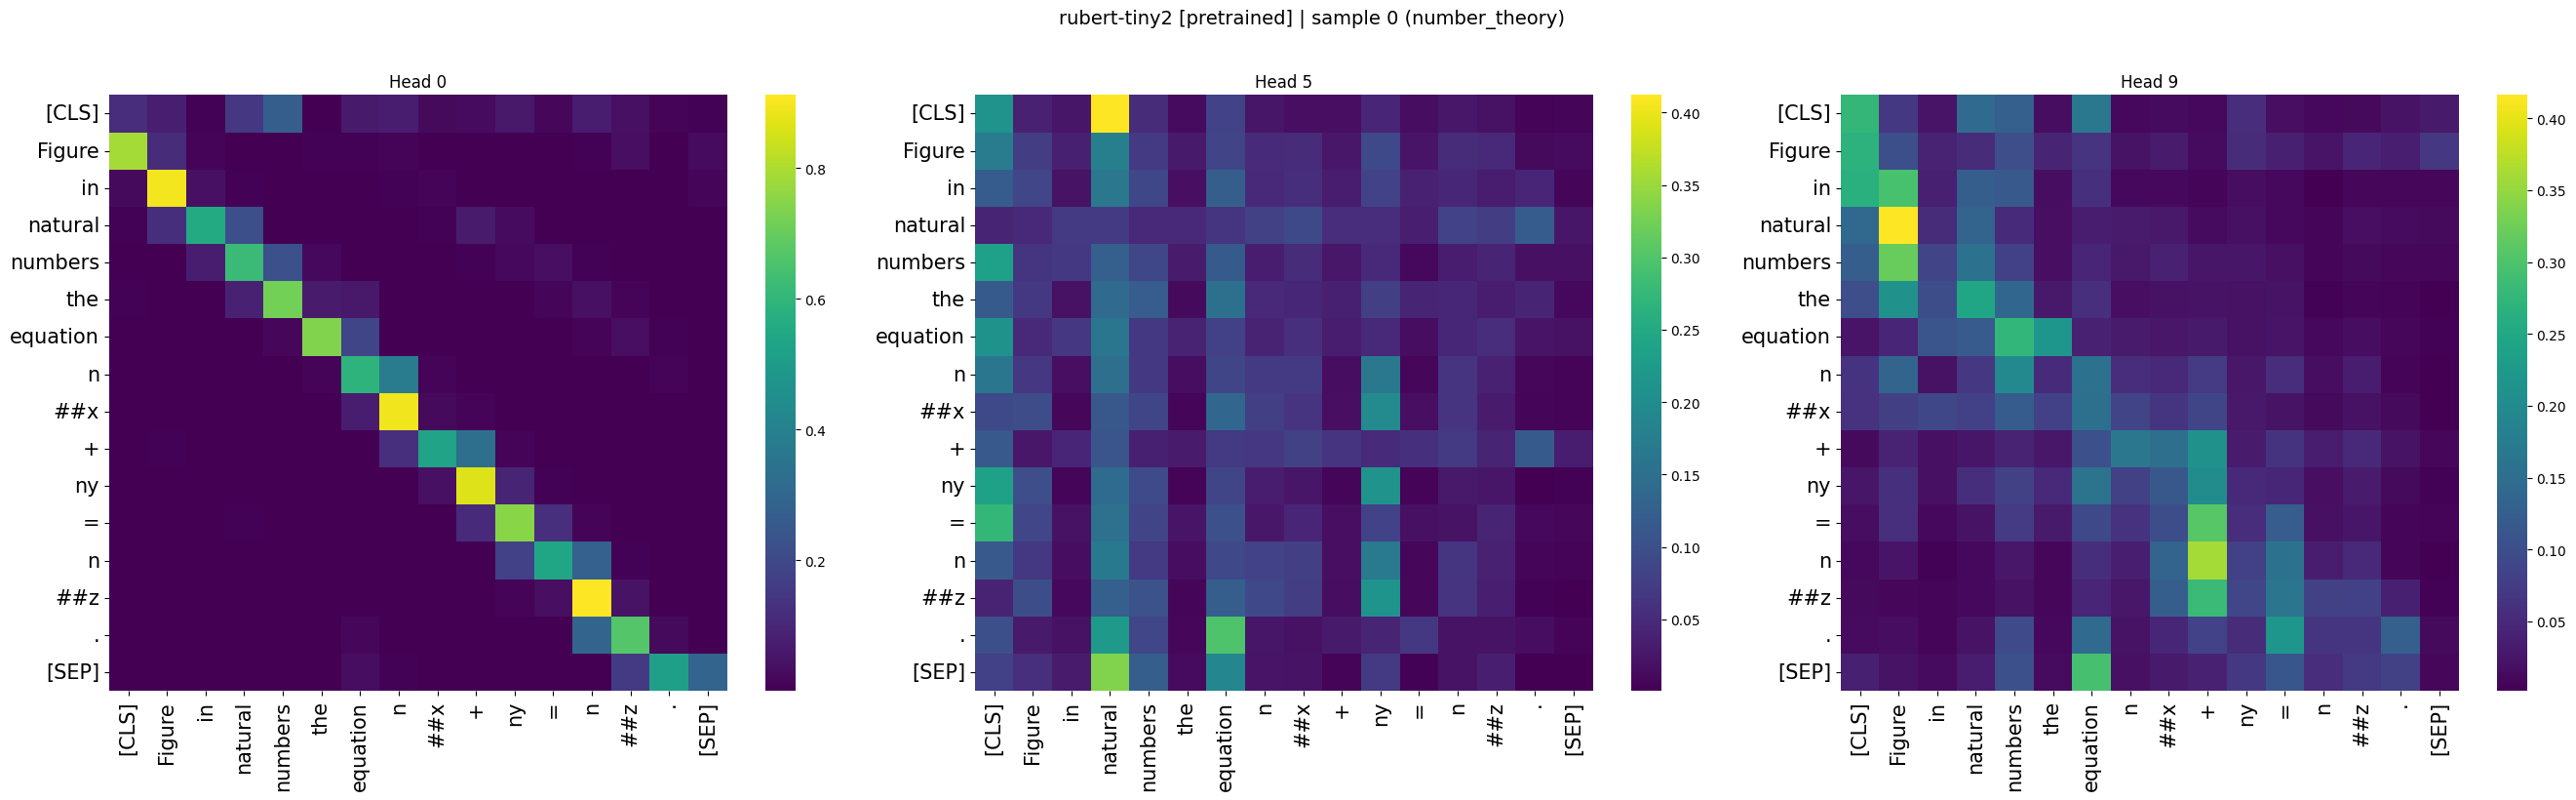

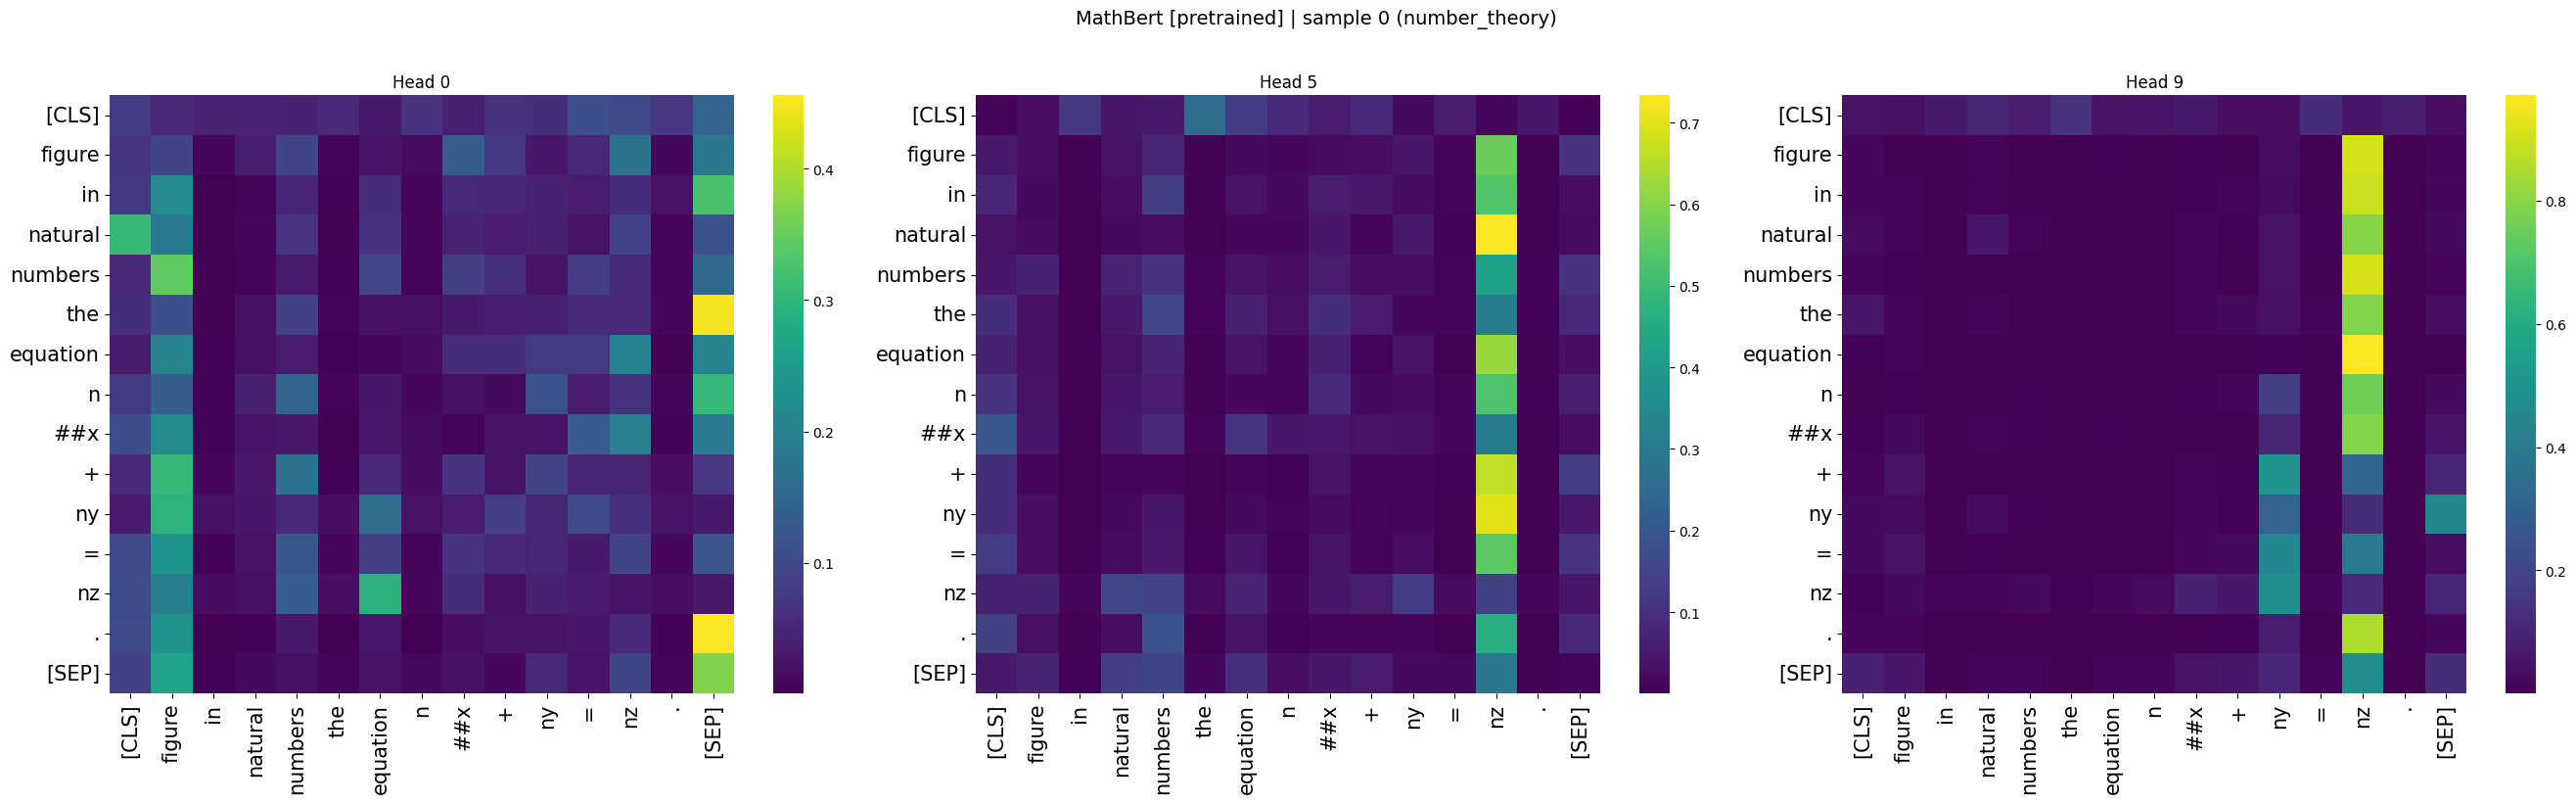

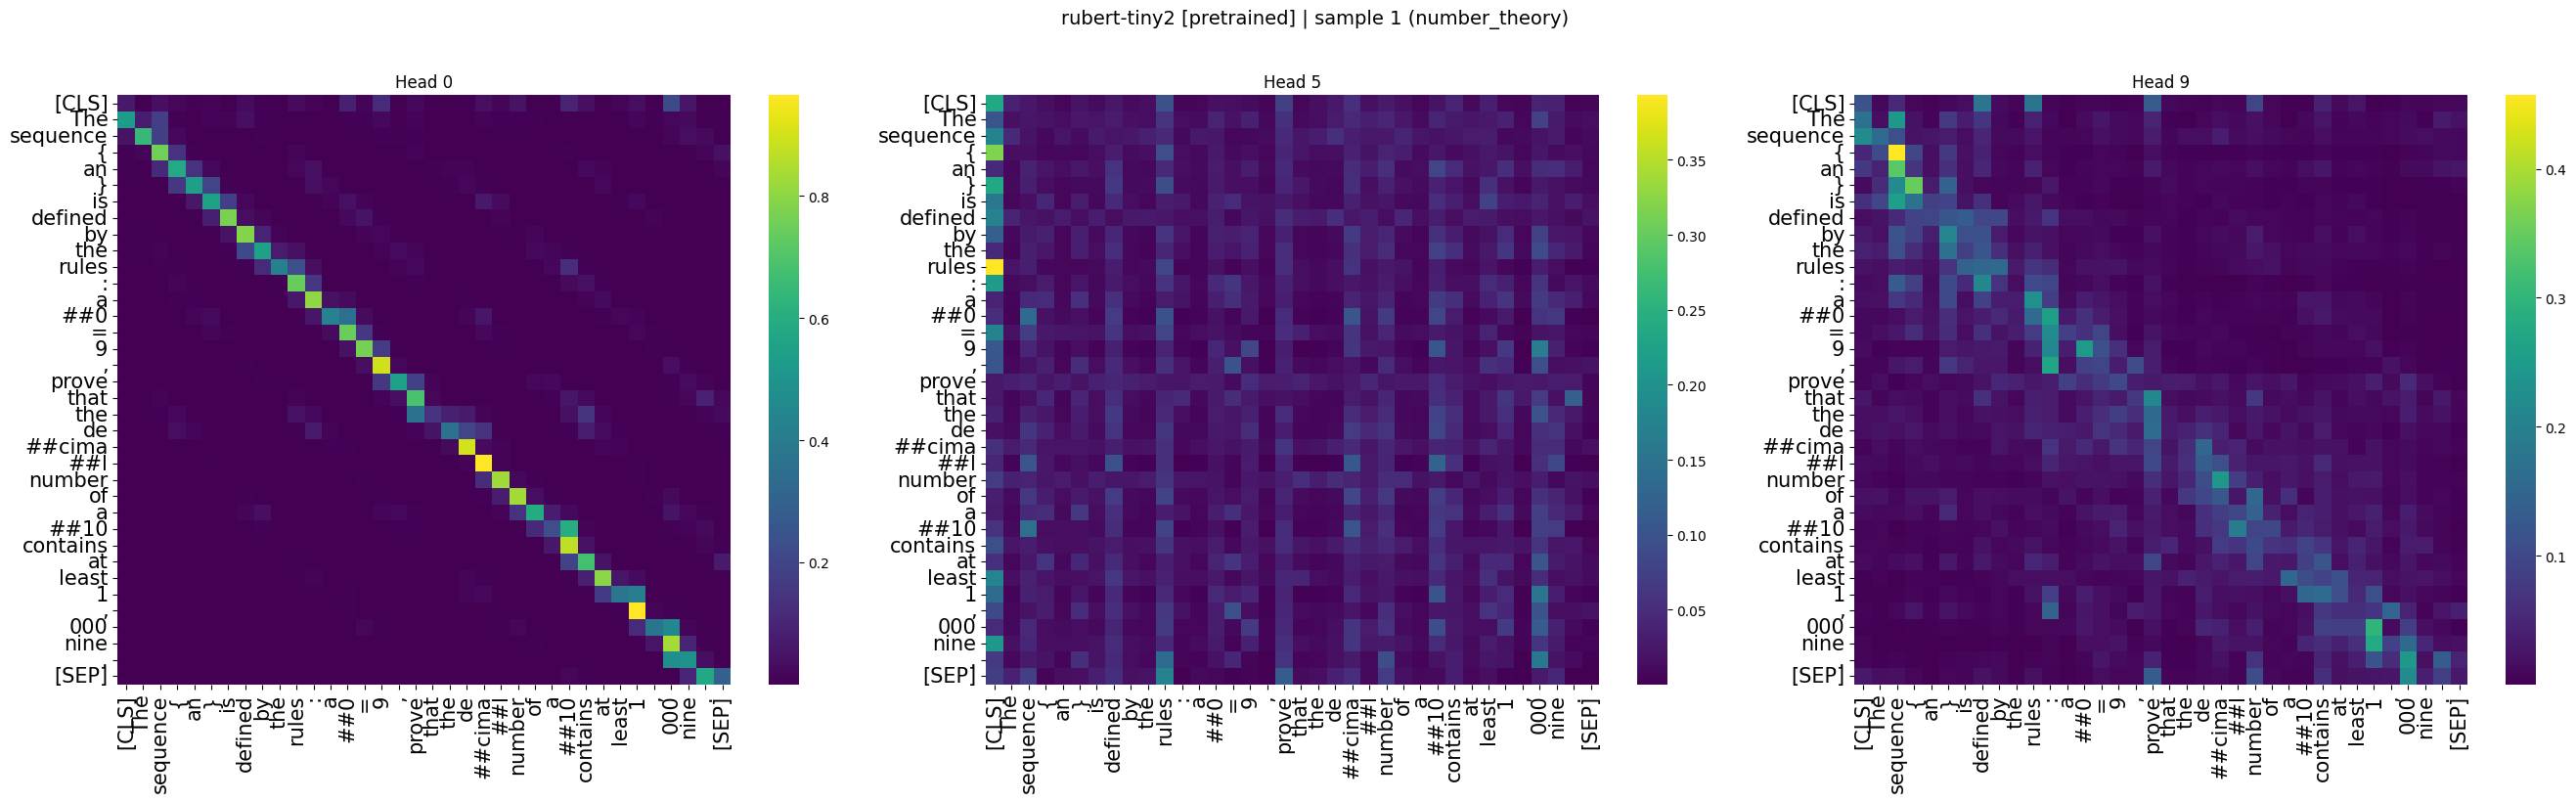

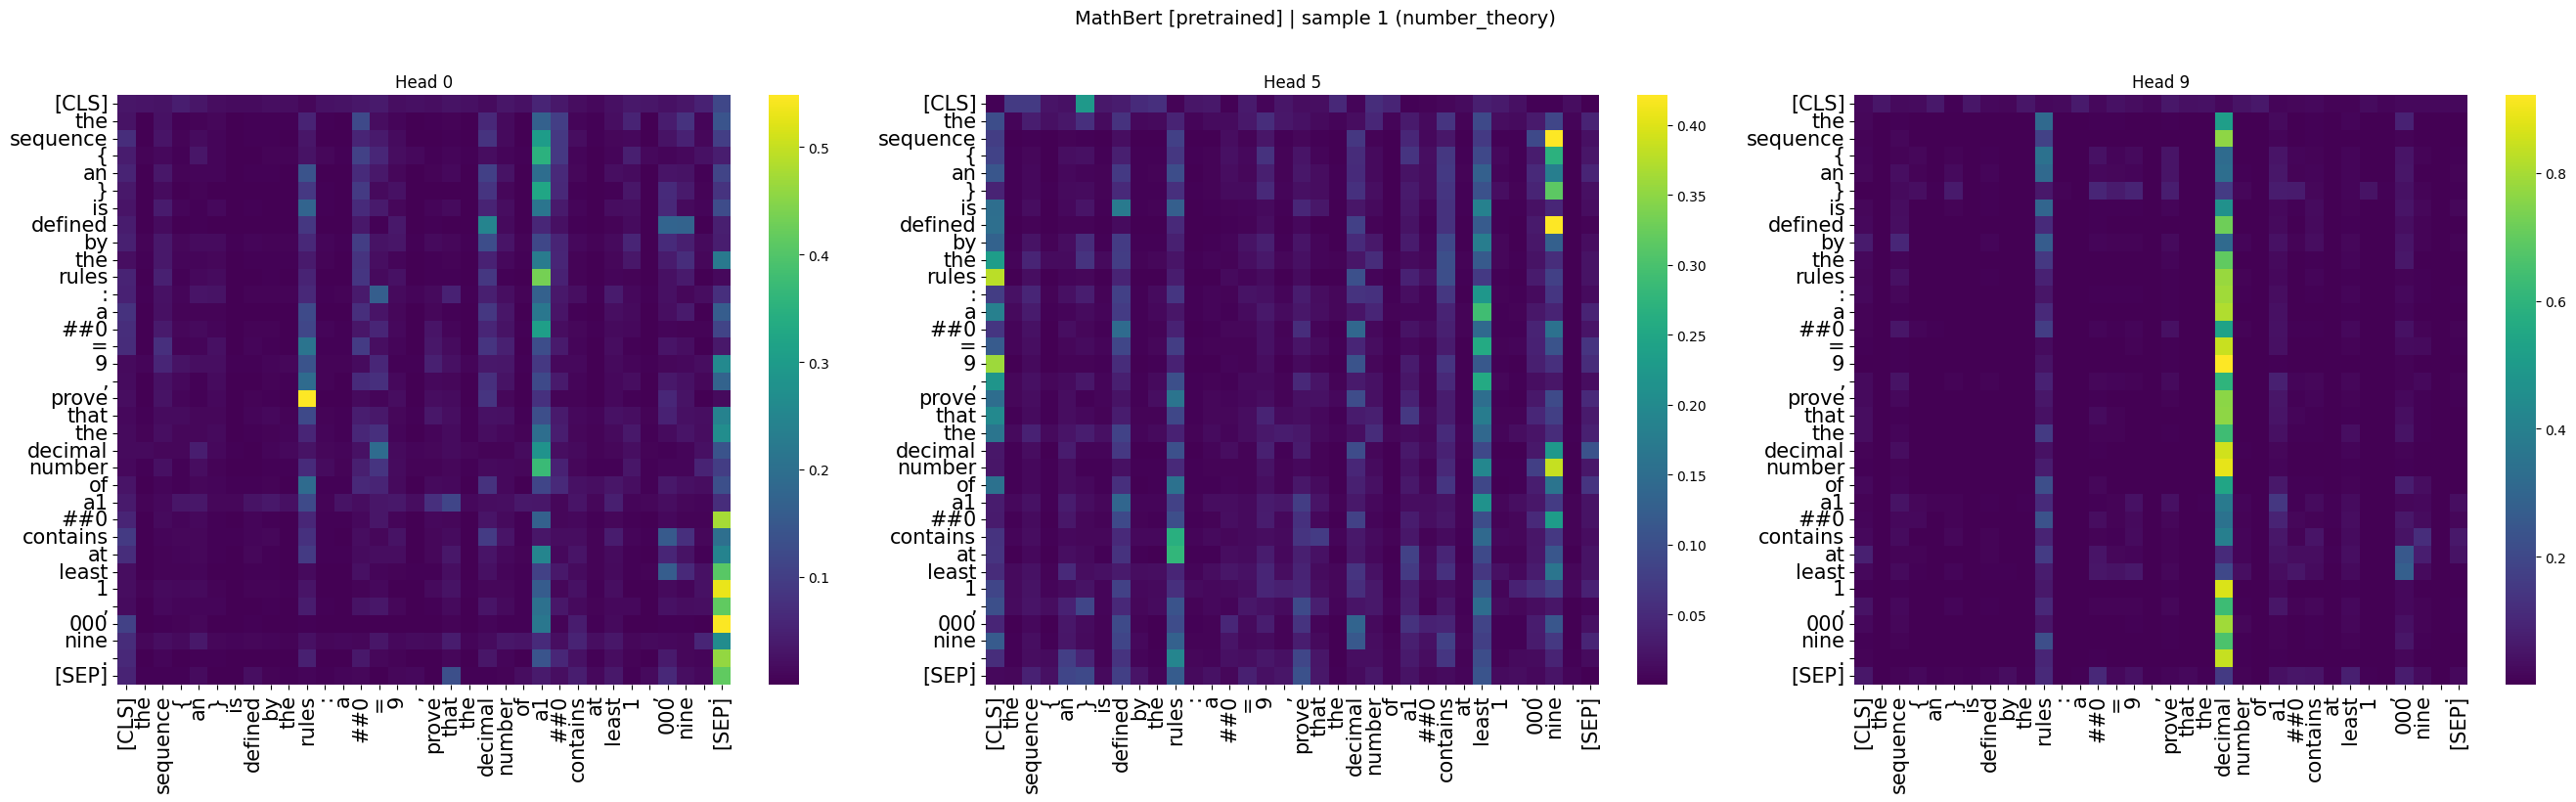

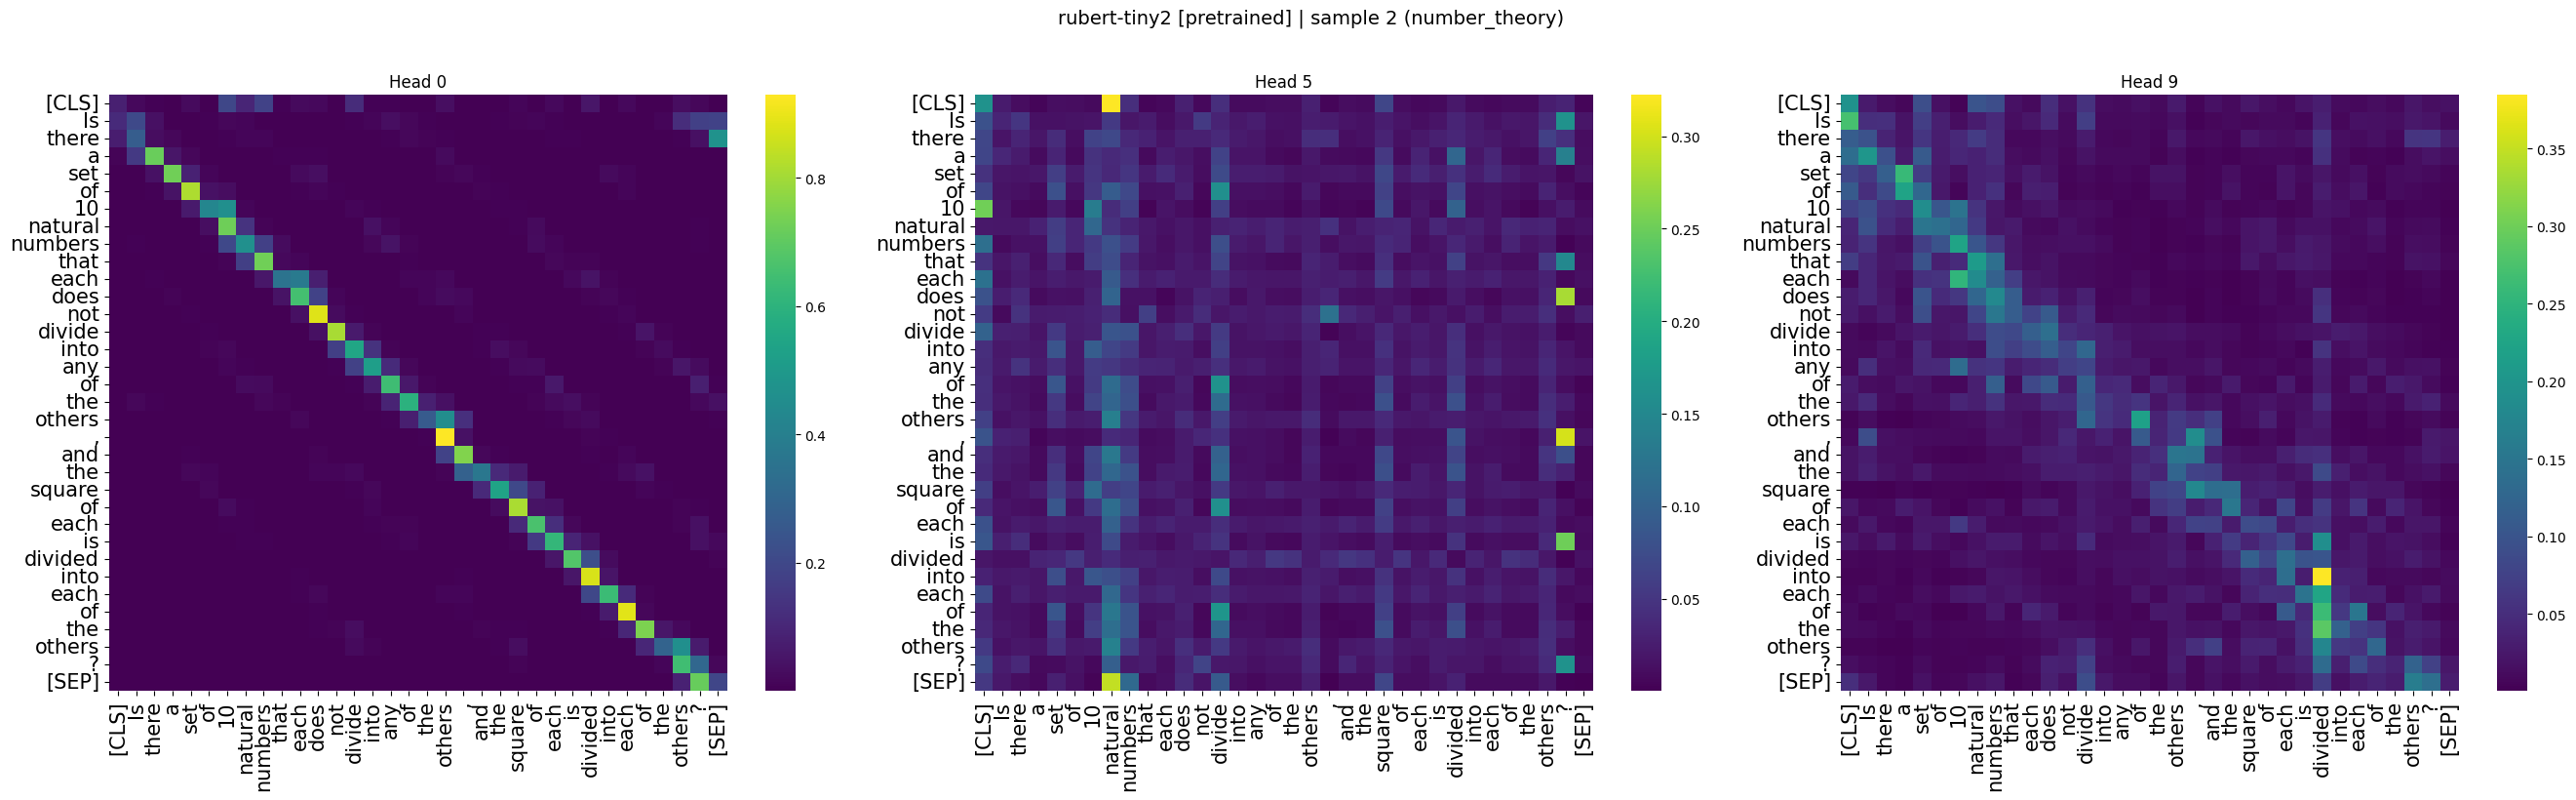

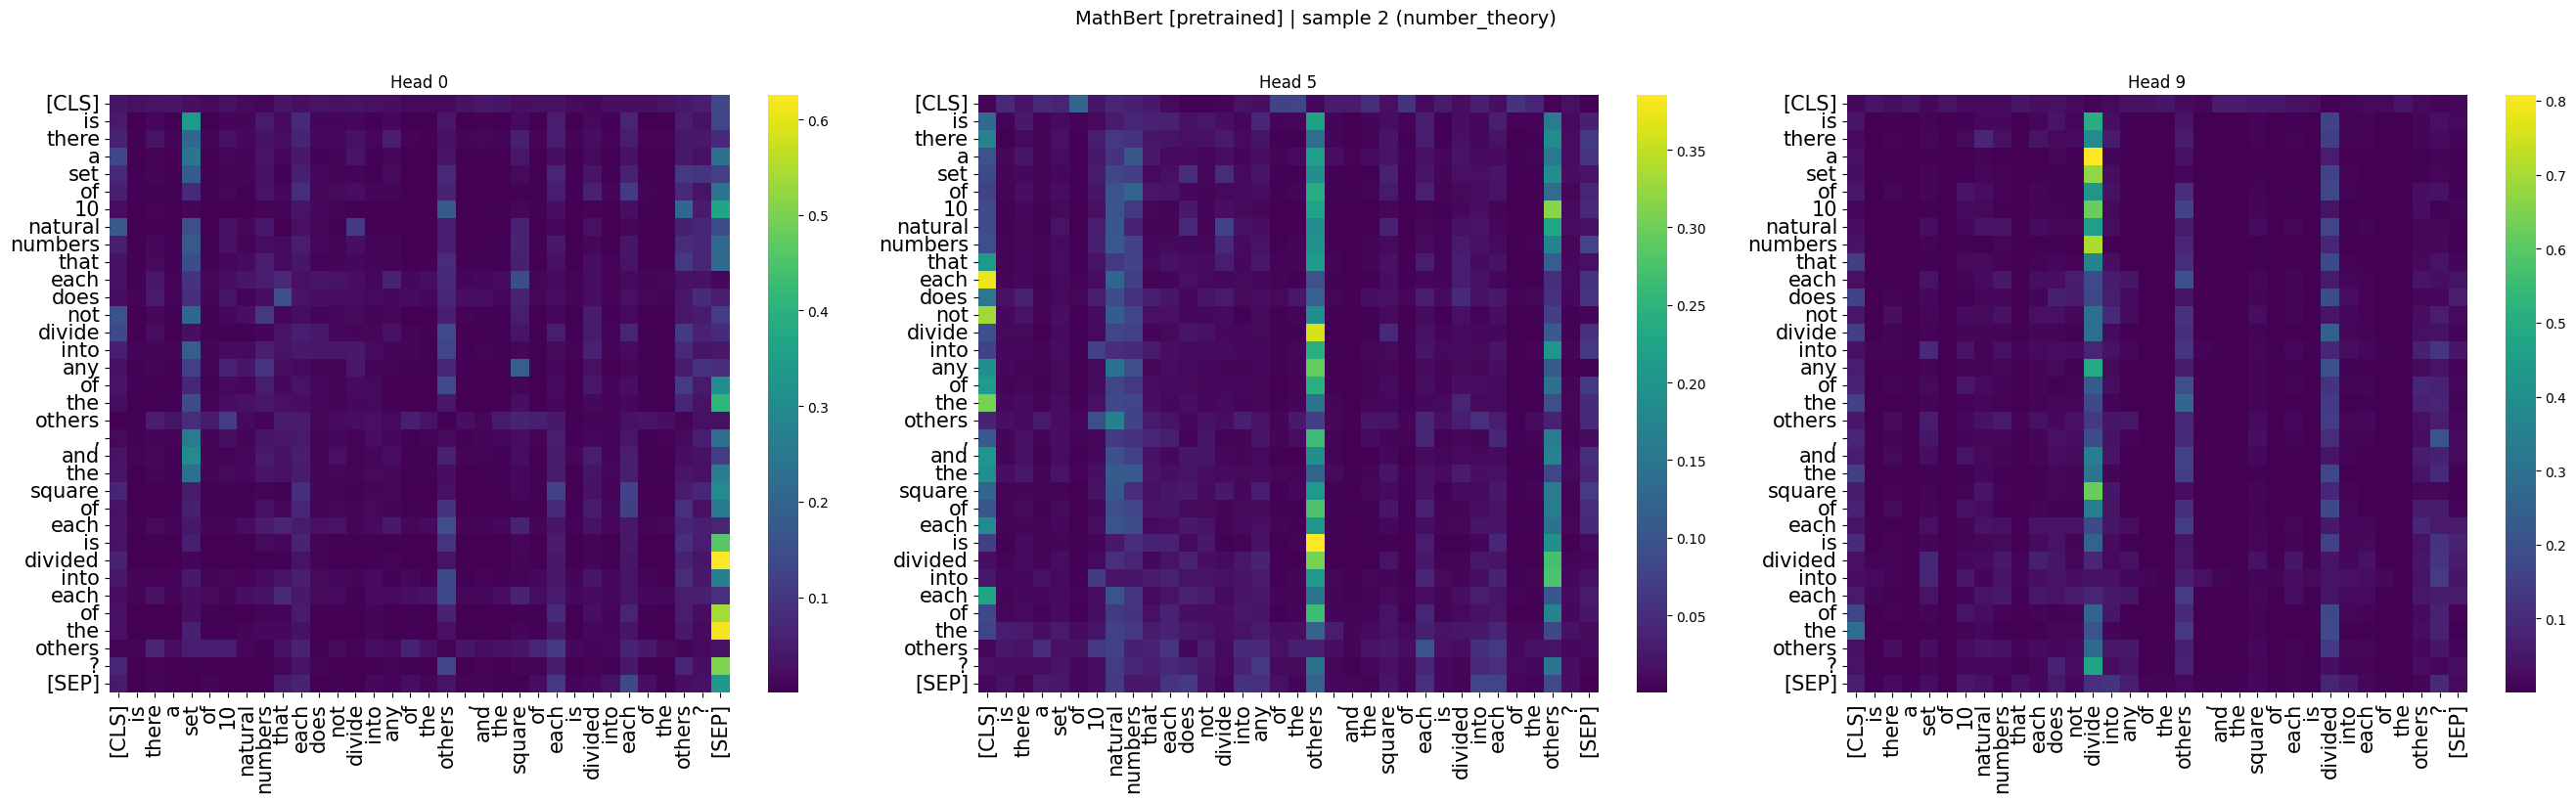

In [45]:
np.random.seed(42)
indices = np.random.choice(len(ds["test"]), size=3, replace=False)
test_samples = ds["test"].select(indices)

base_rubert   = TransformerClassificationModel("cointegrated/rubert-tiny2")
base_mathbert = TransformerClassificationModel("tbs17/MathBert")

for i, sample in enumerate(test_samples):
    text = sample["problem_text"]
    topic = topics[sample["topic"]]
    tag = f"sample {i} ({topic})"
    draw_first_layer_attention_maps([0, 5, 9], text, base_rubert,   "cointegrated/rubert-tiny2",
                                    title=f"rubert-tiny2 [pretrained] | {tag}")
    draw_first_layer_attention_maps([0, 5, 9], text, base_mathbert, "tbs17/MathBert",
                                    title=f"MathBert [pretrained] | {tag}")

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

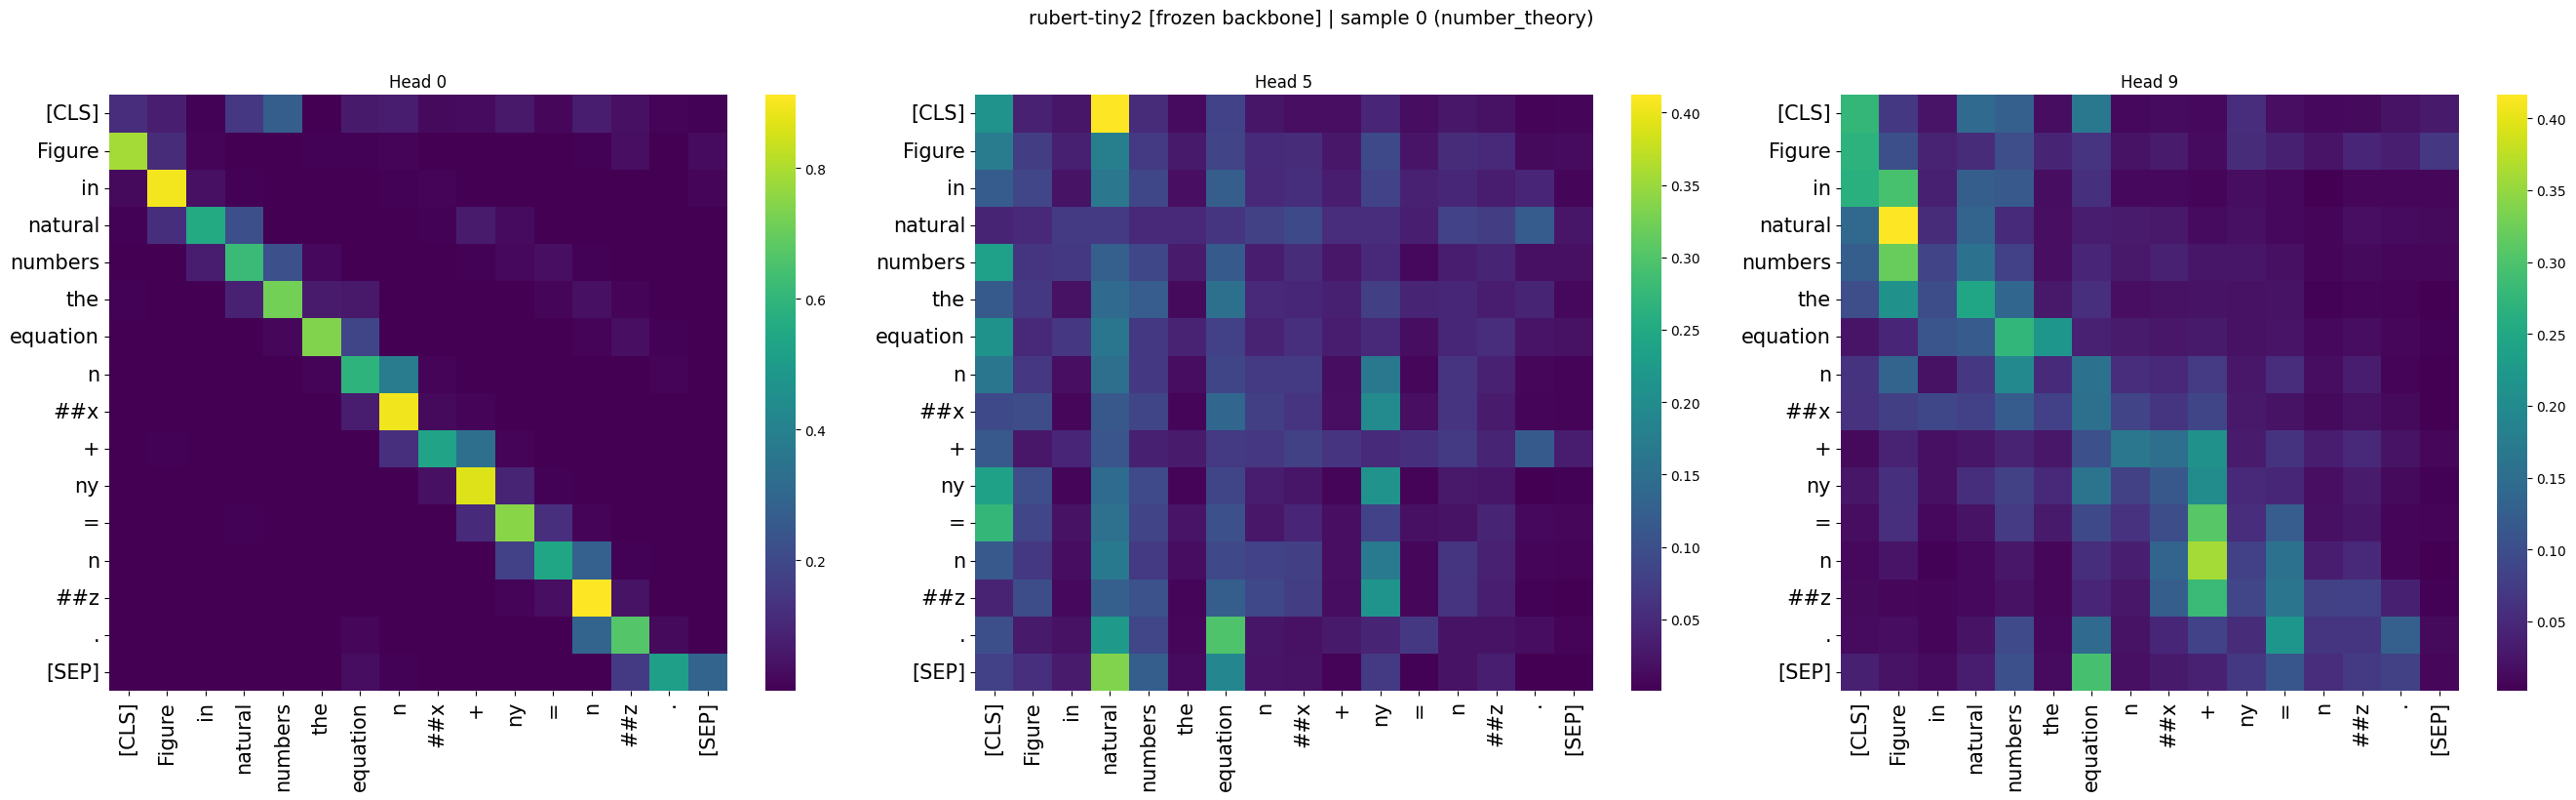

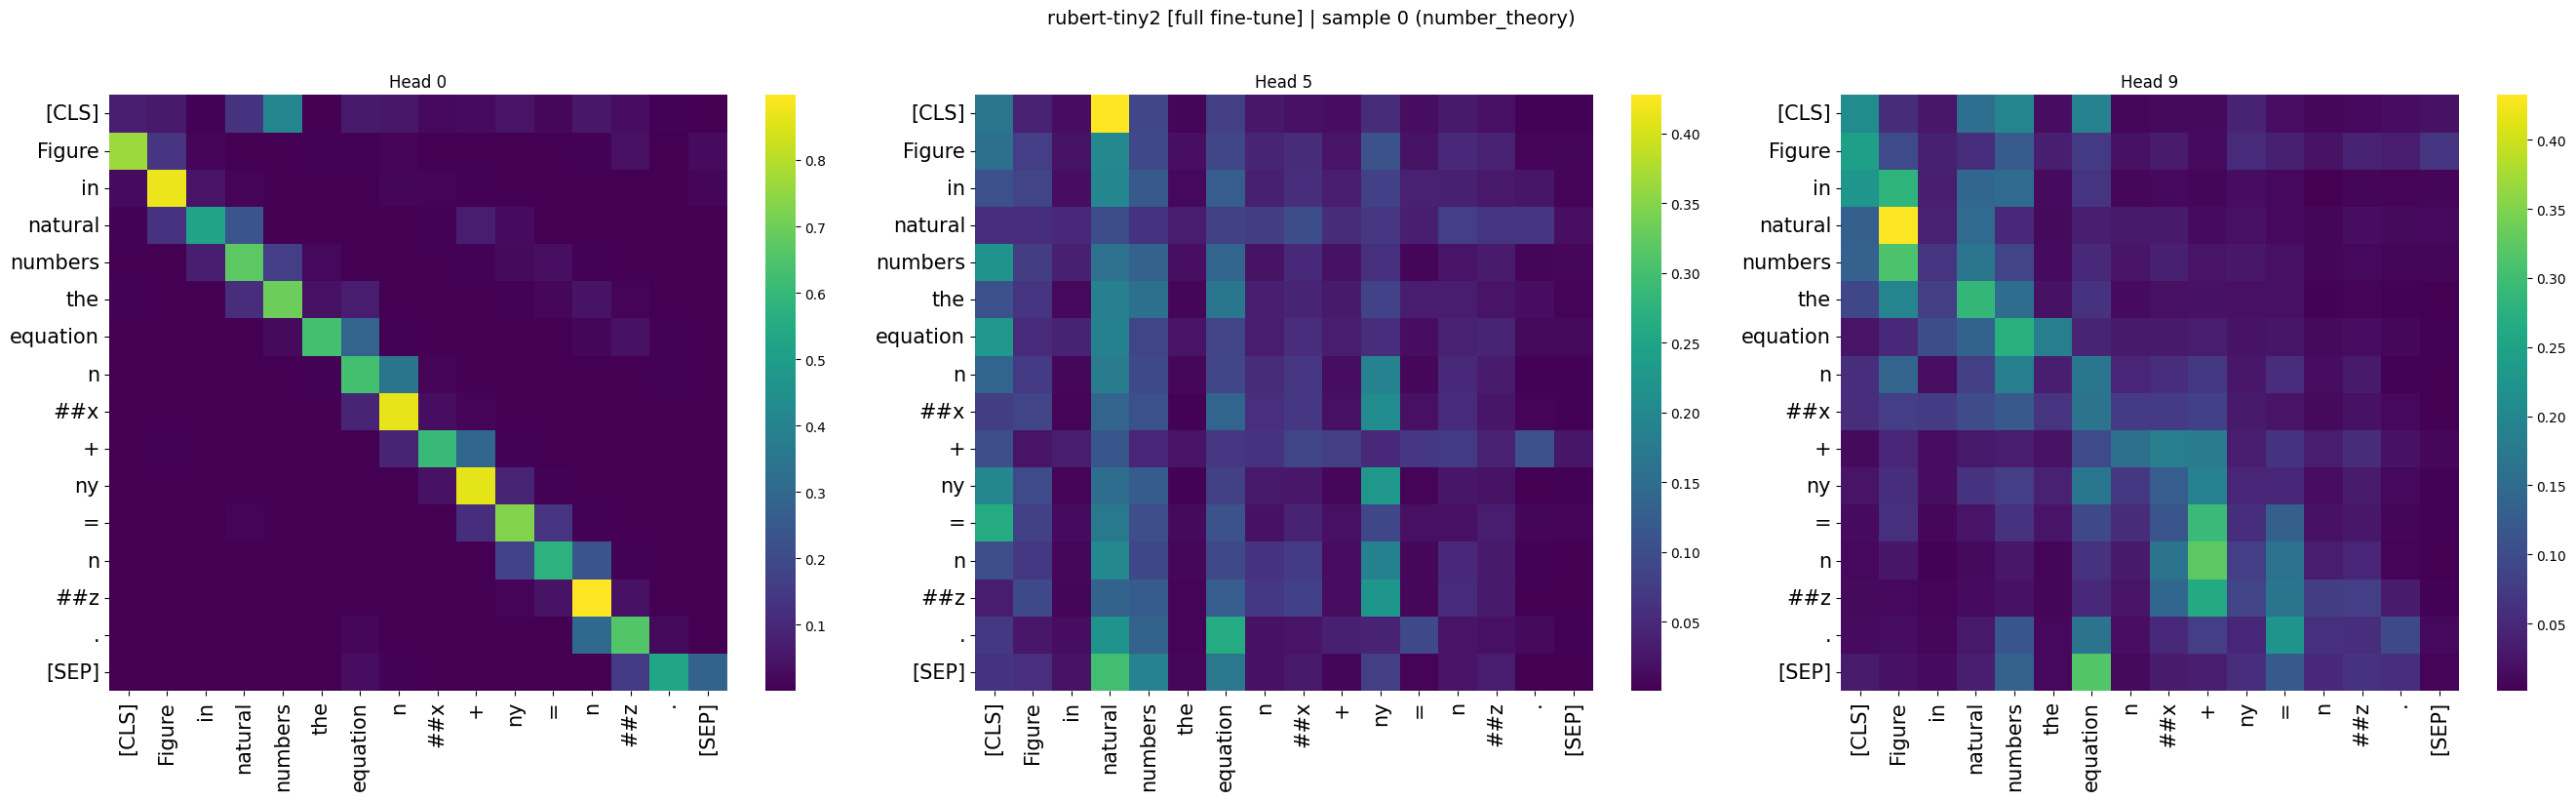

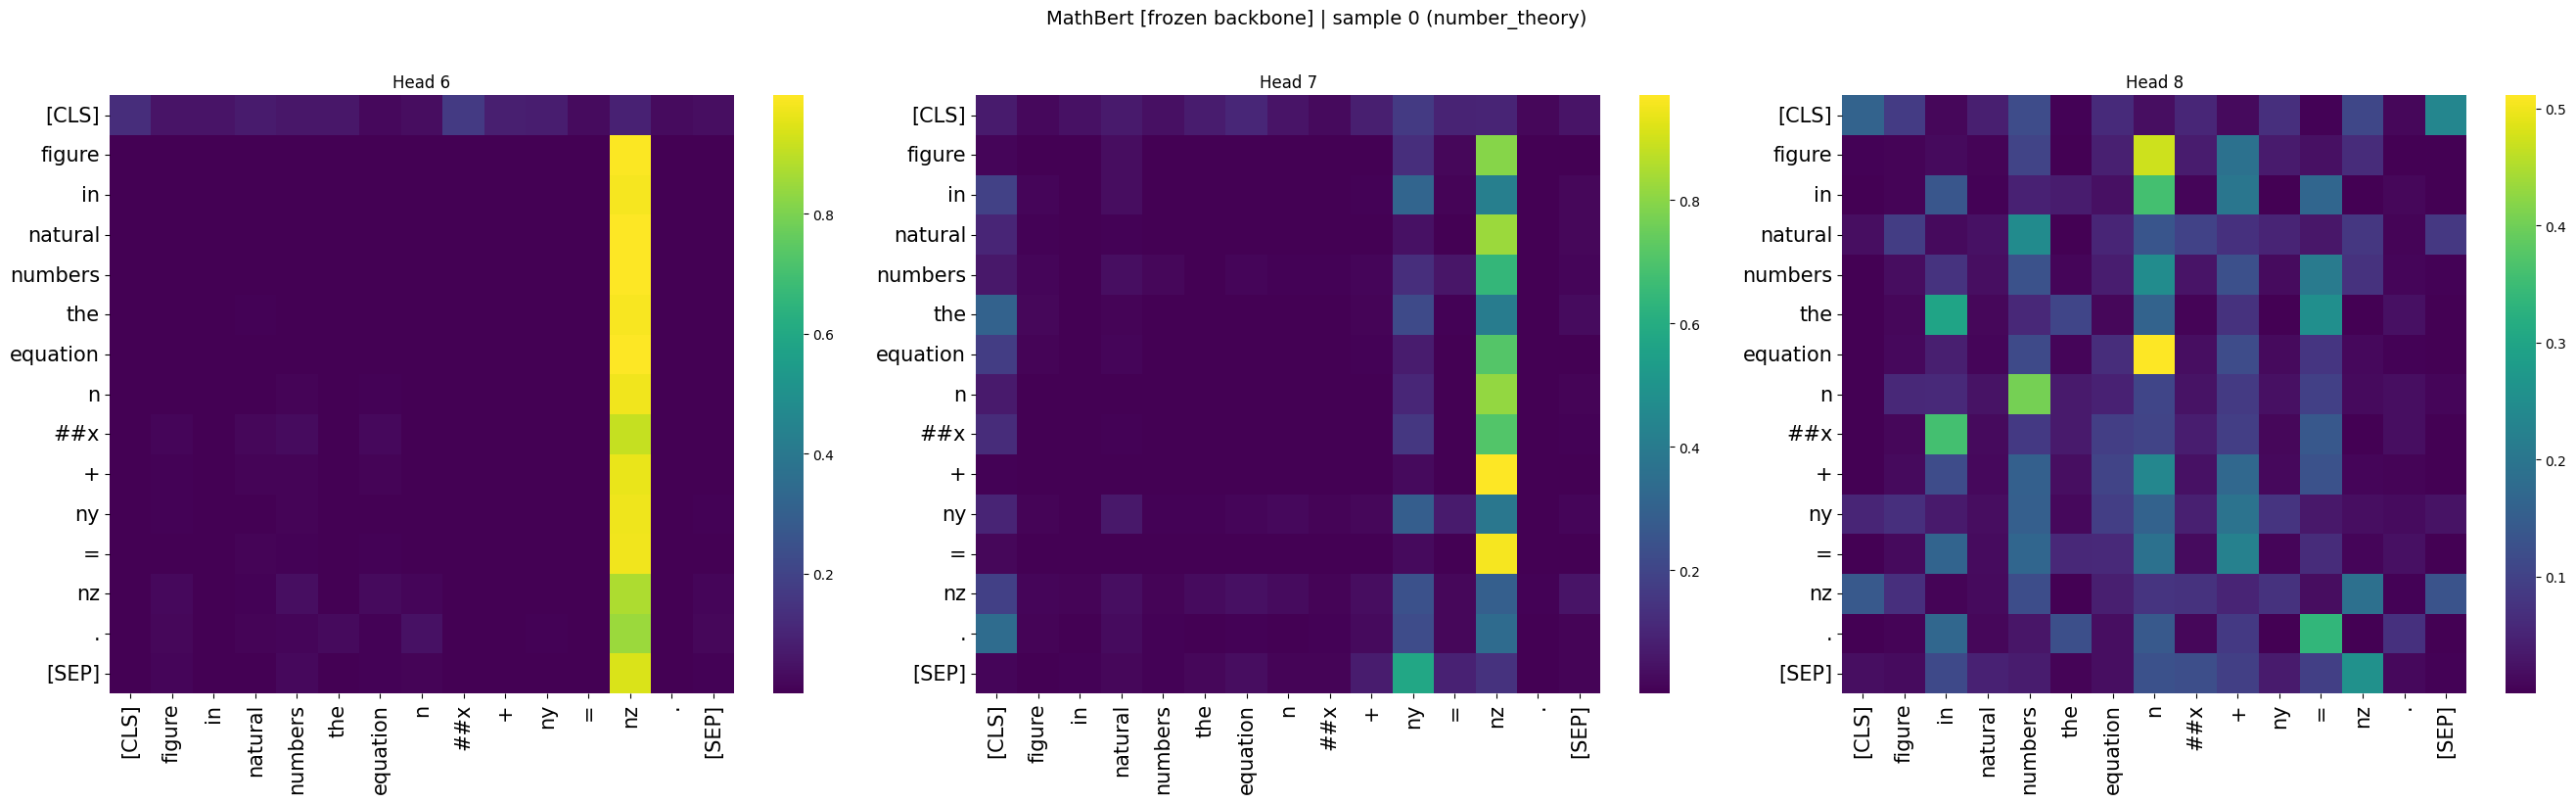

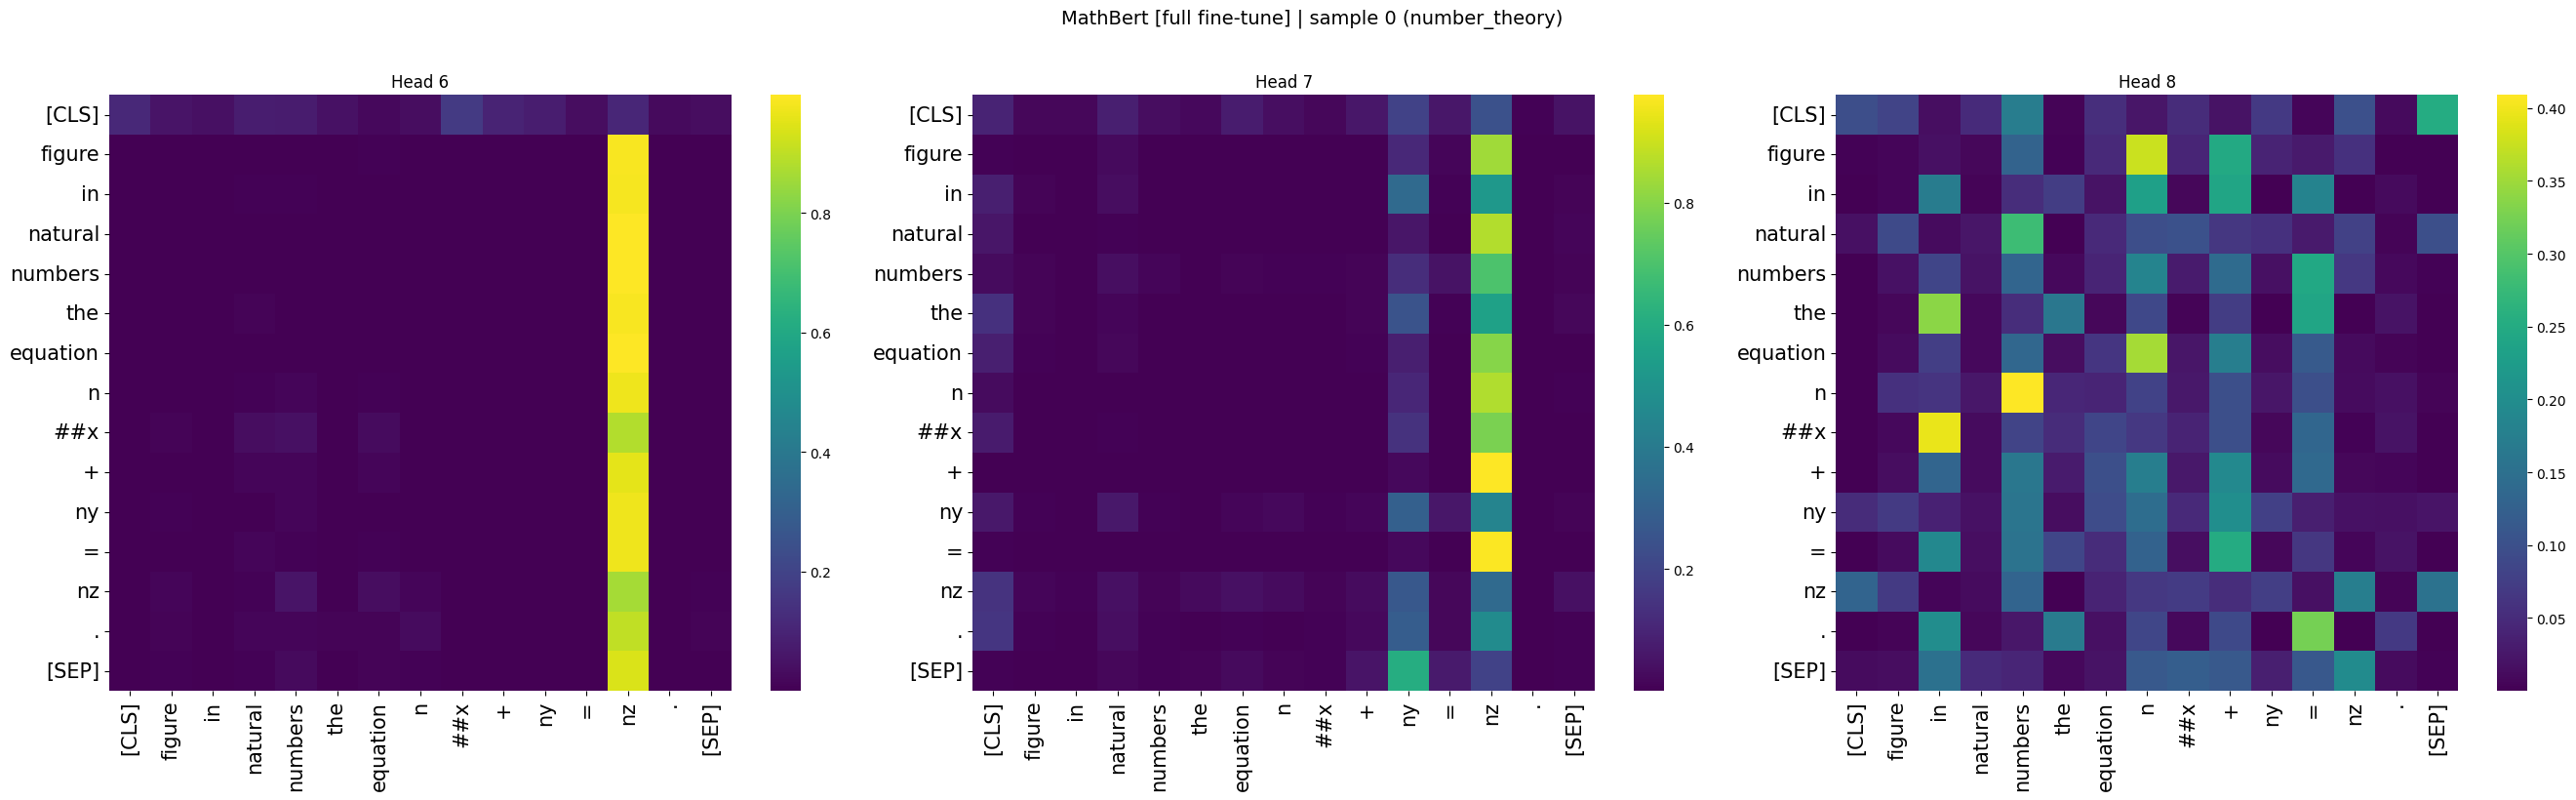

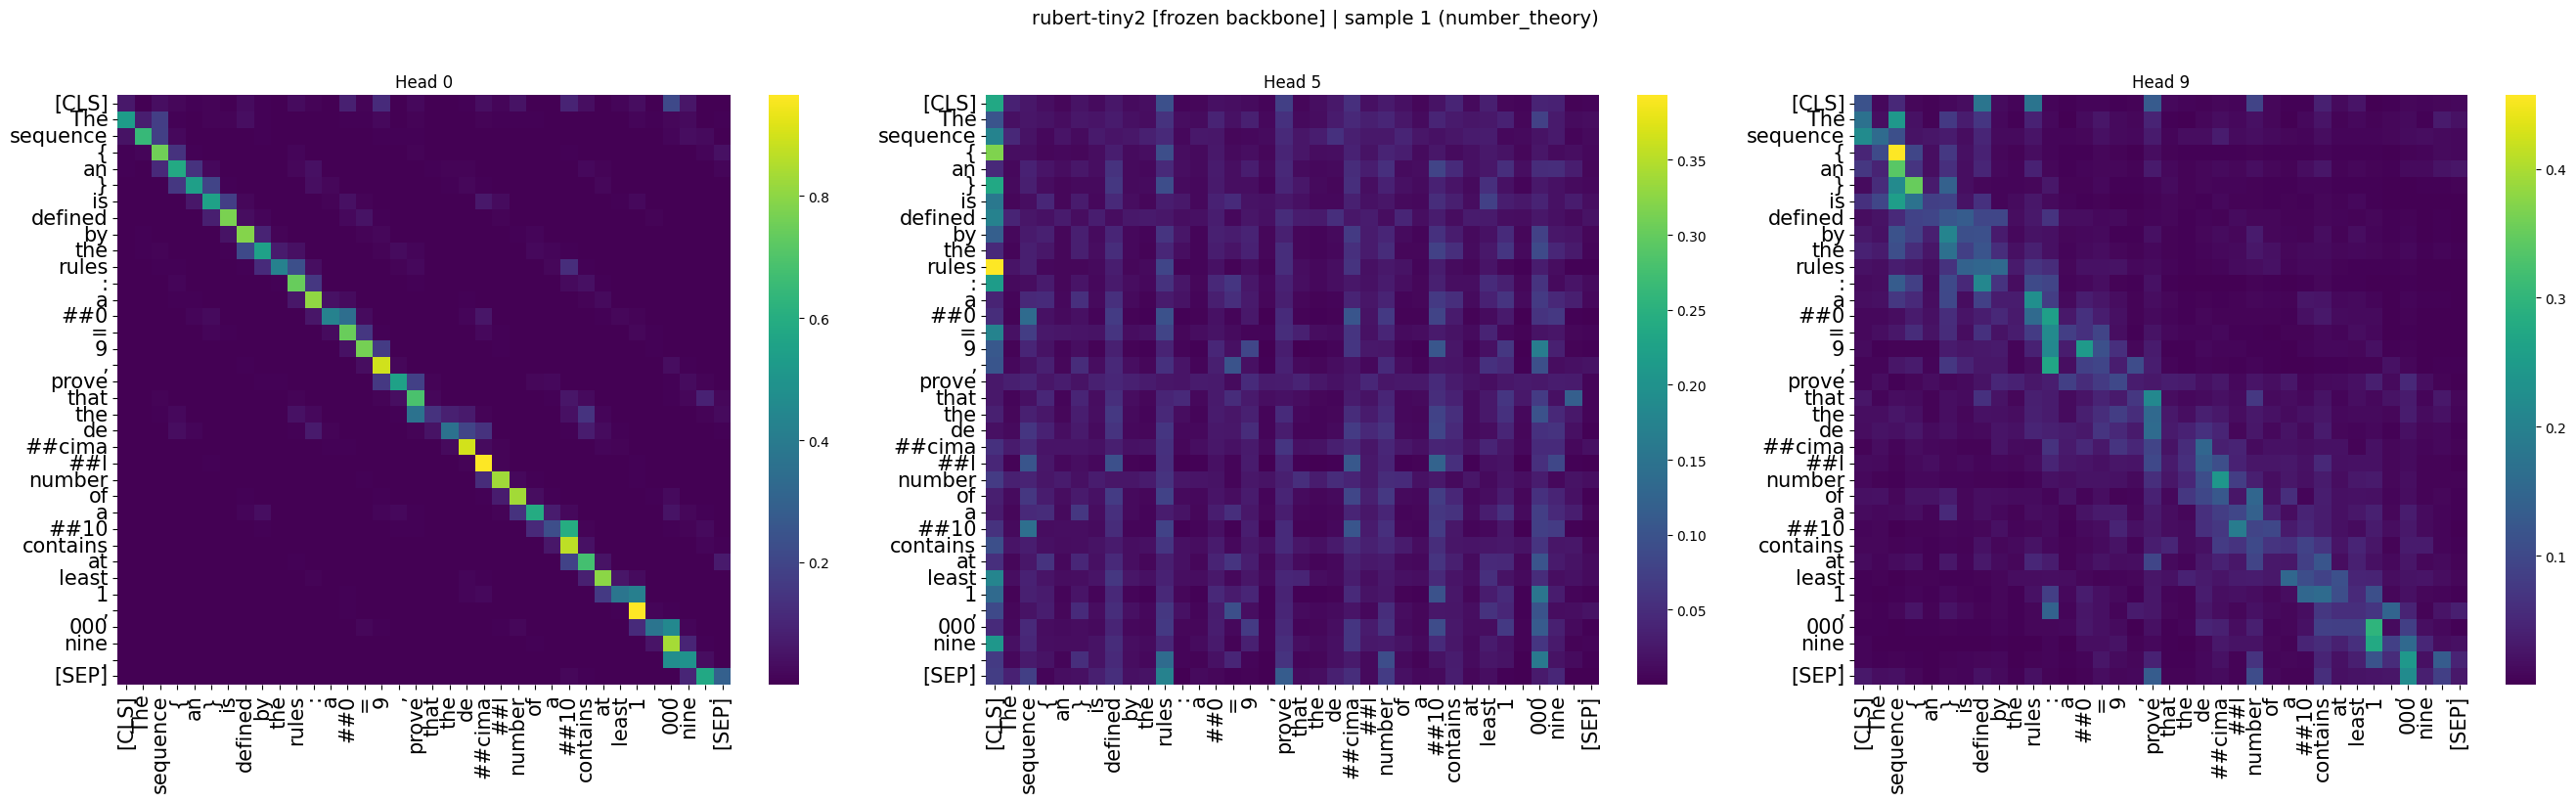

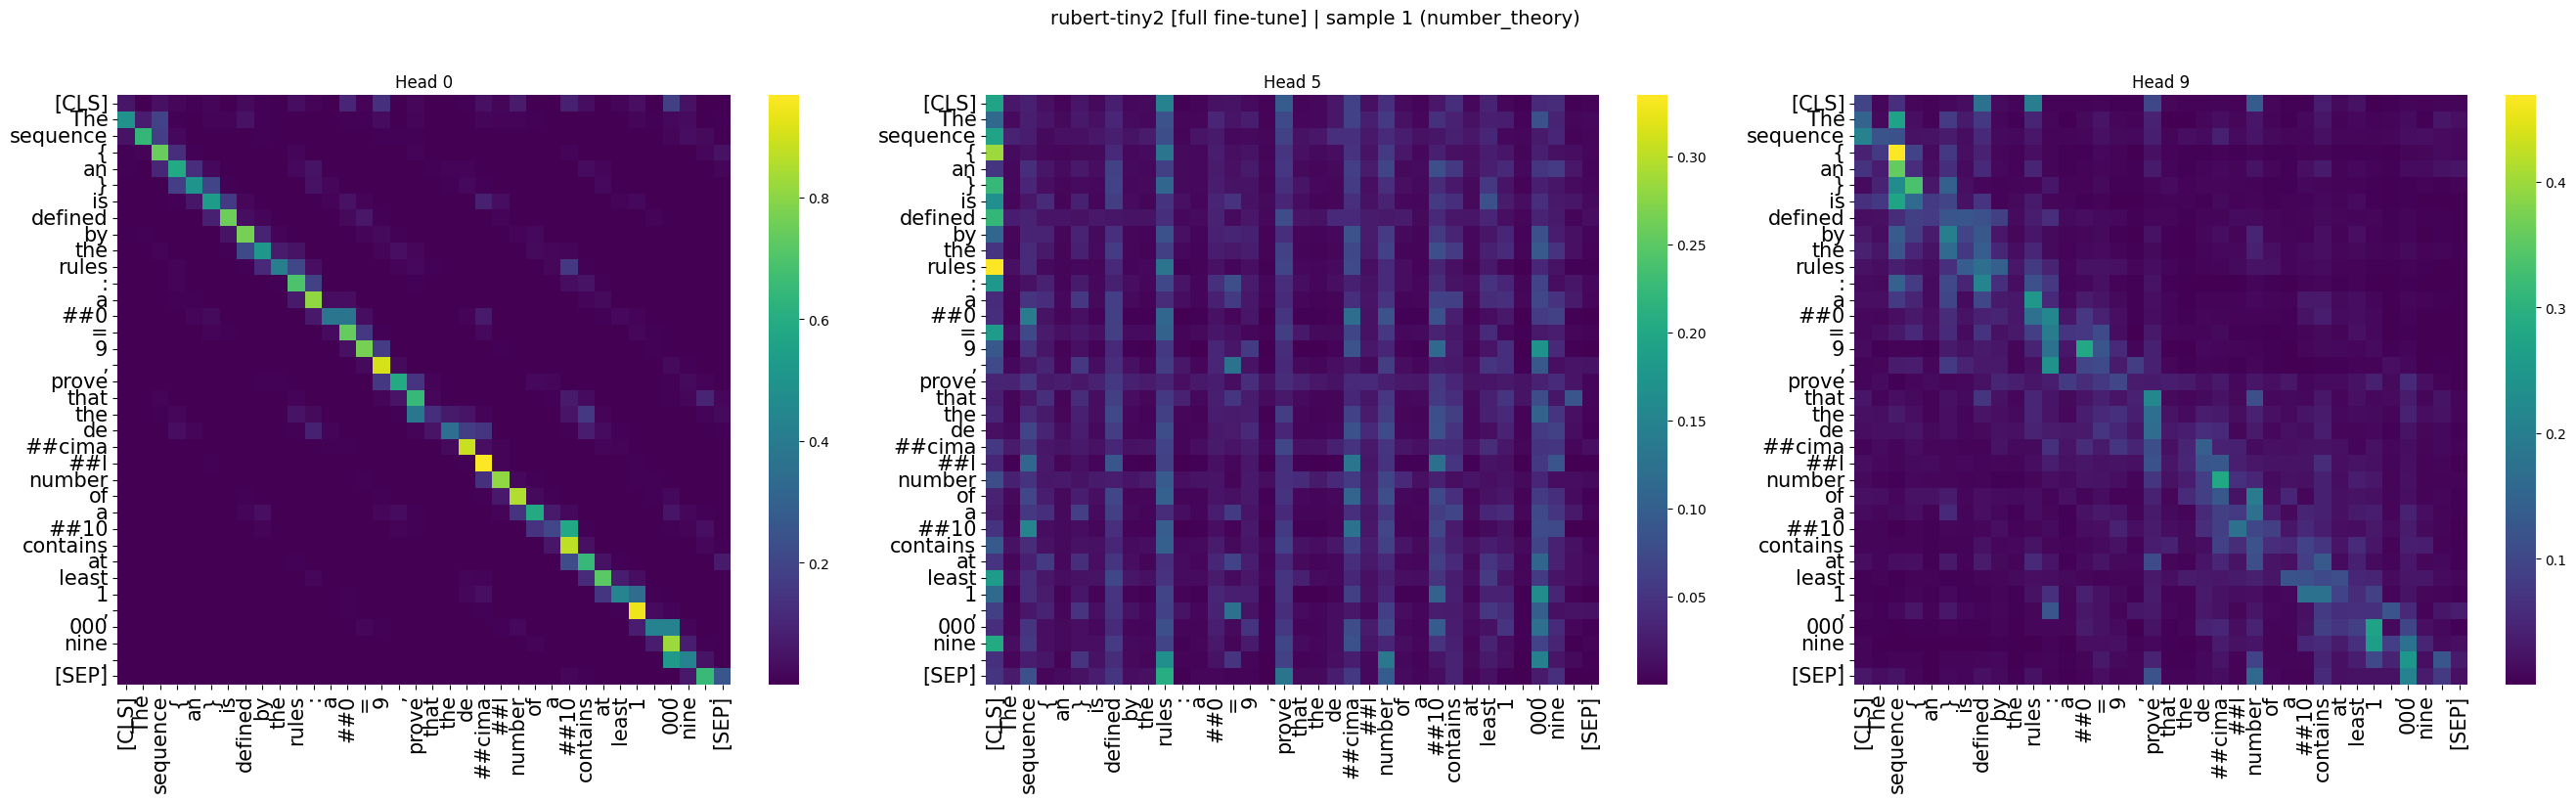

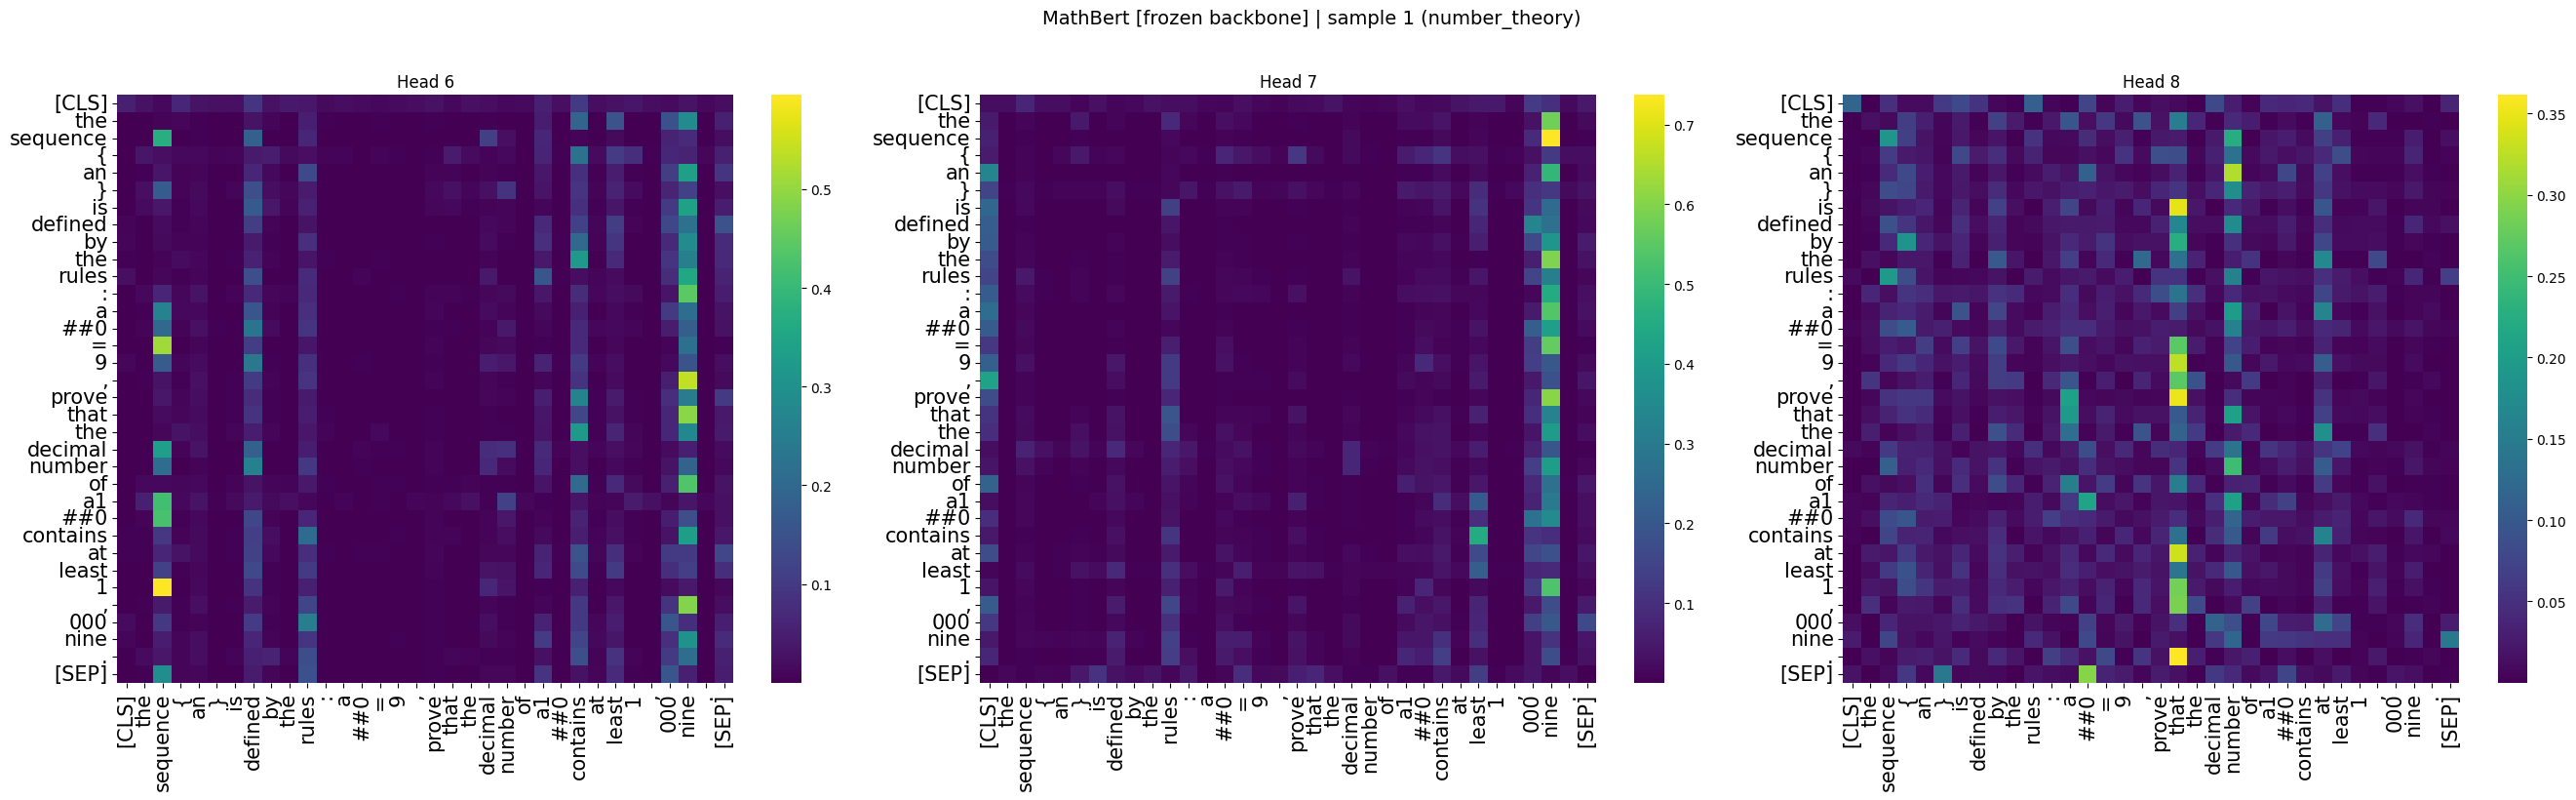

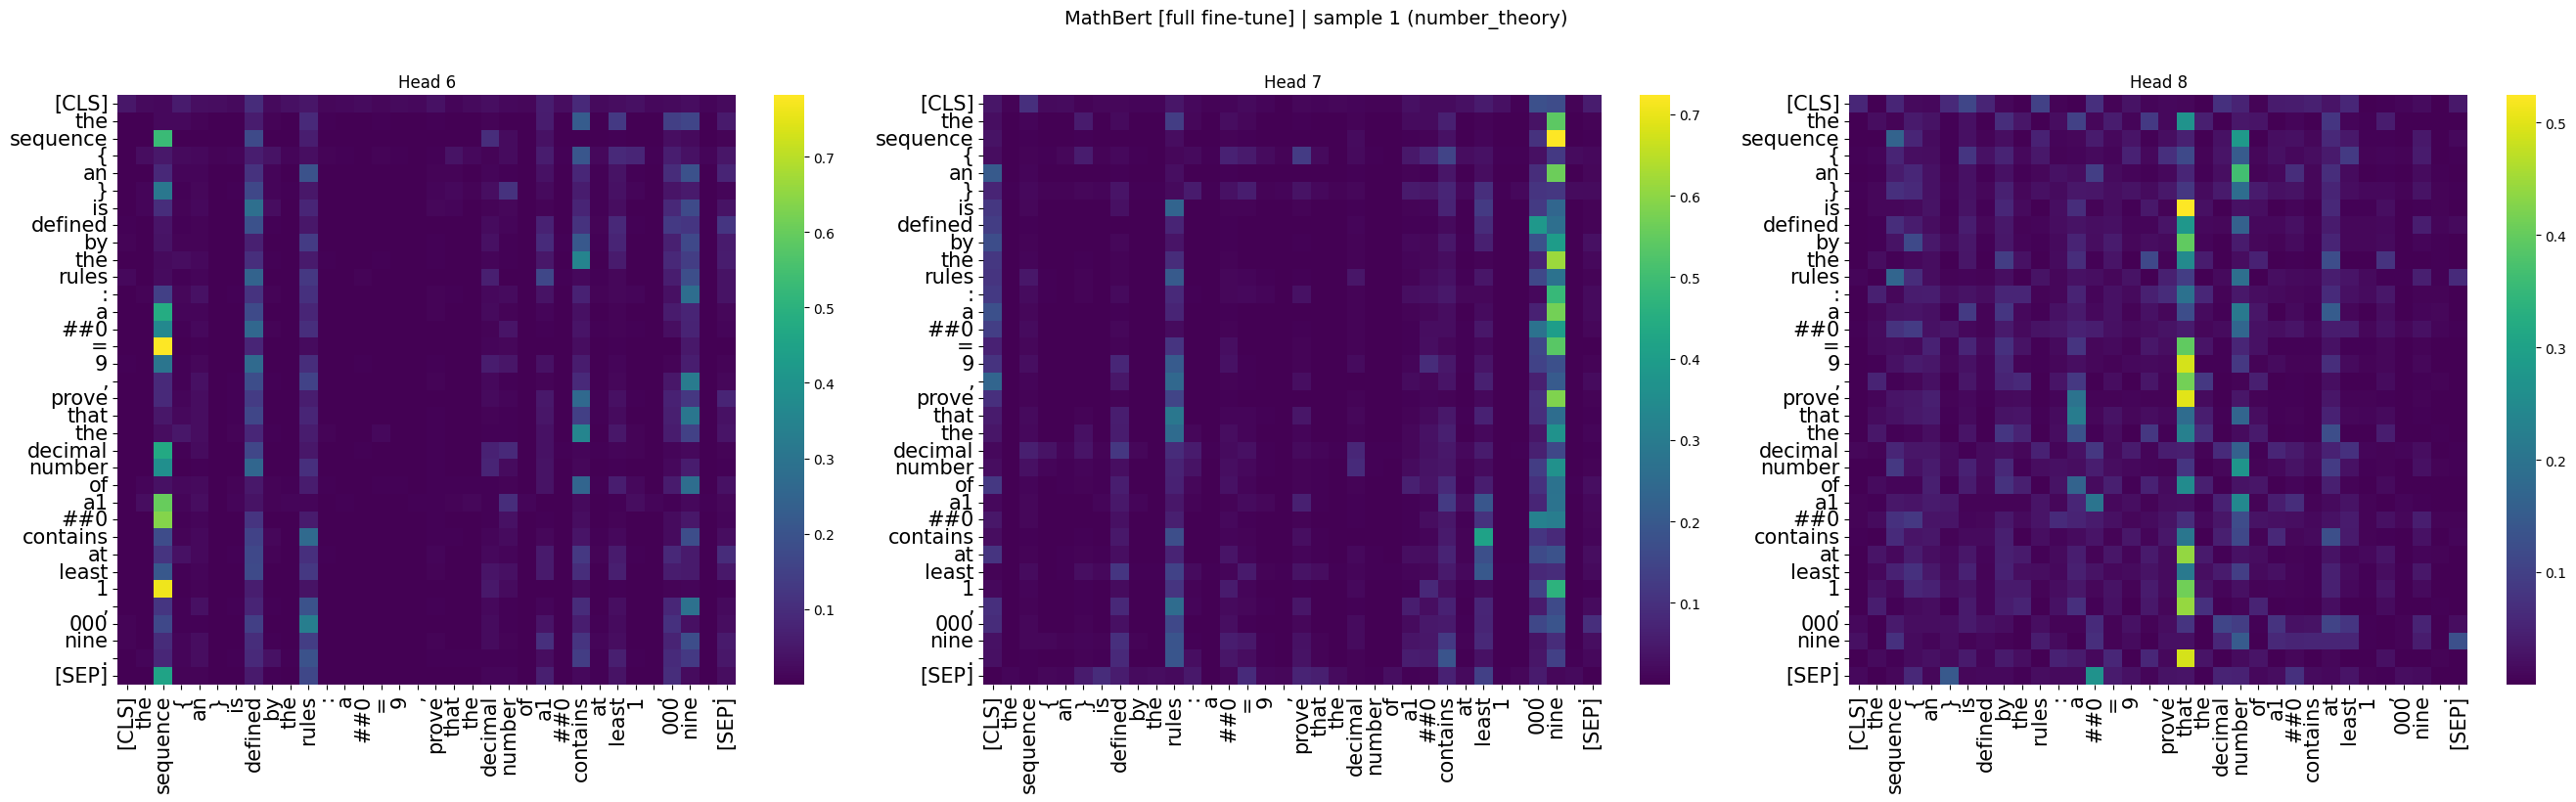

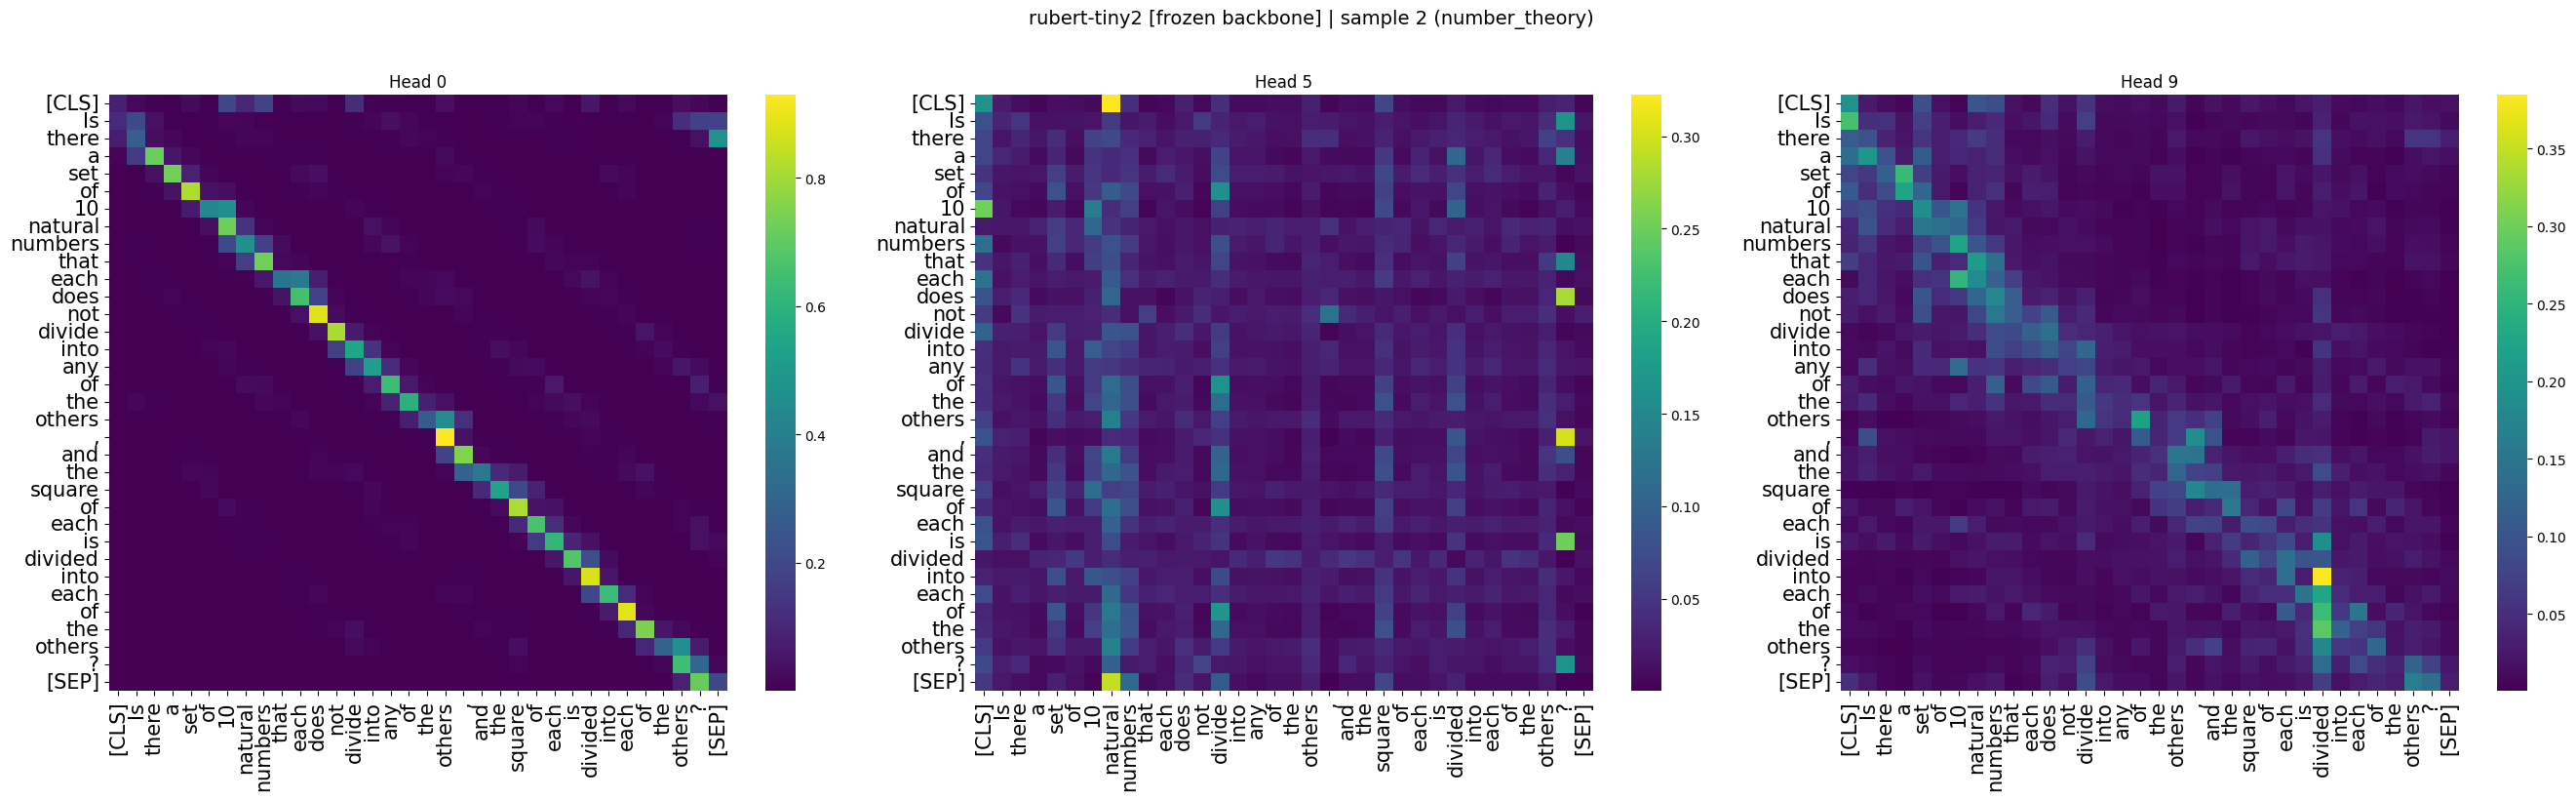

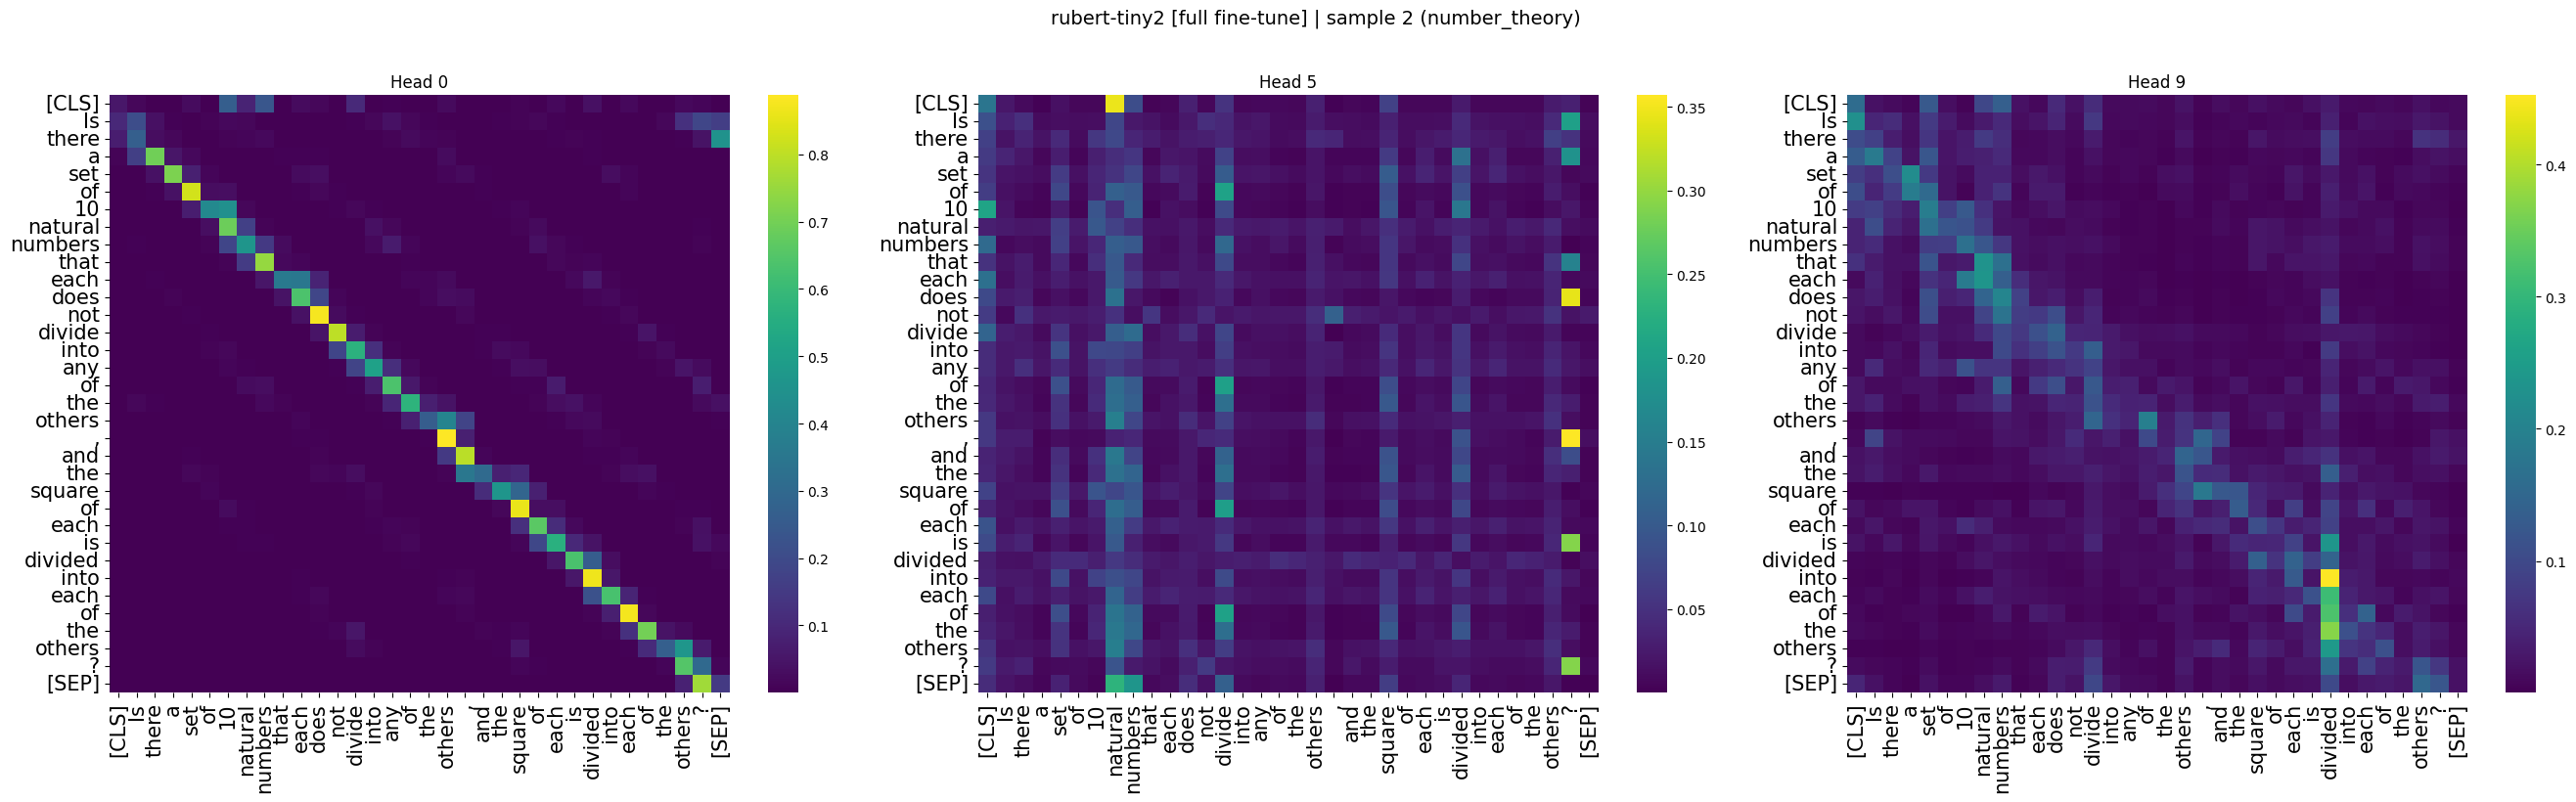

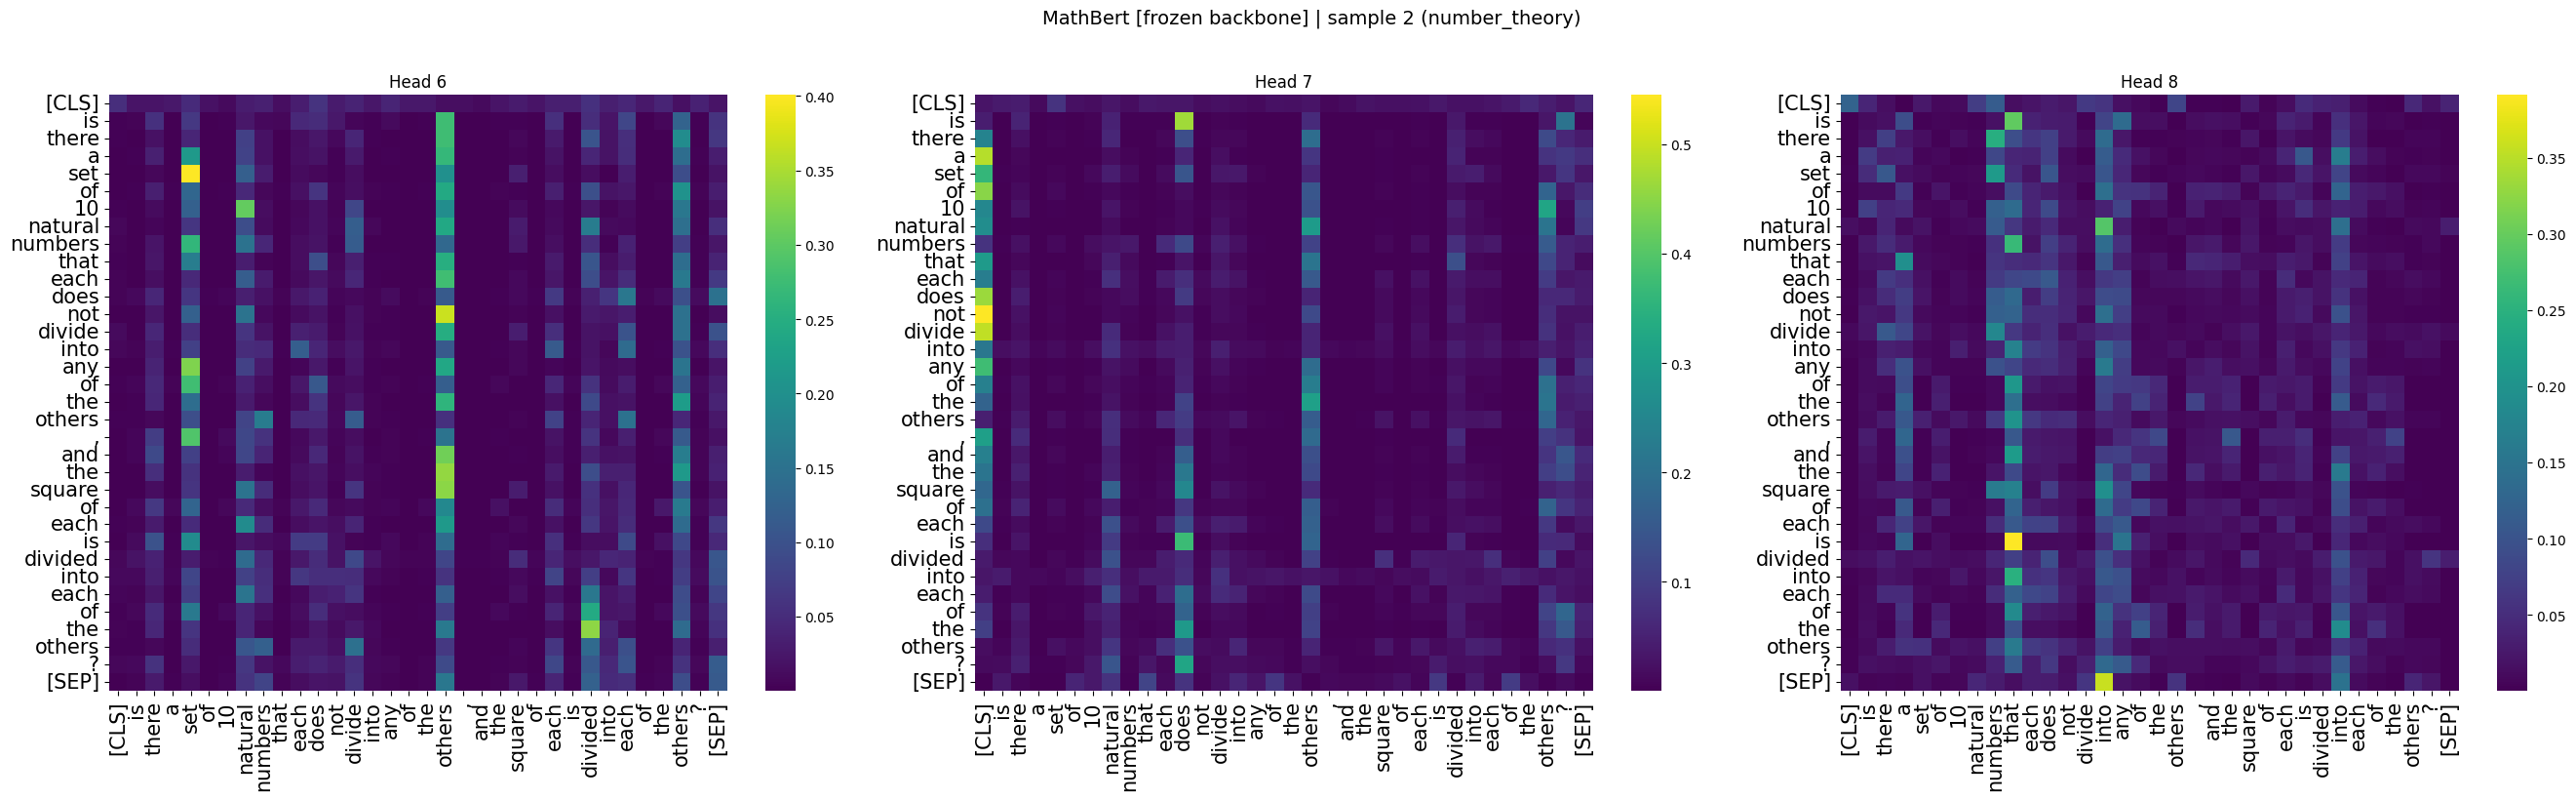

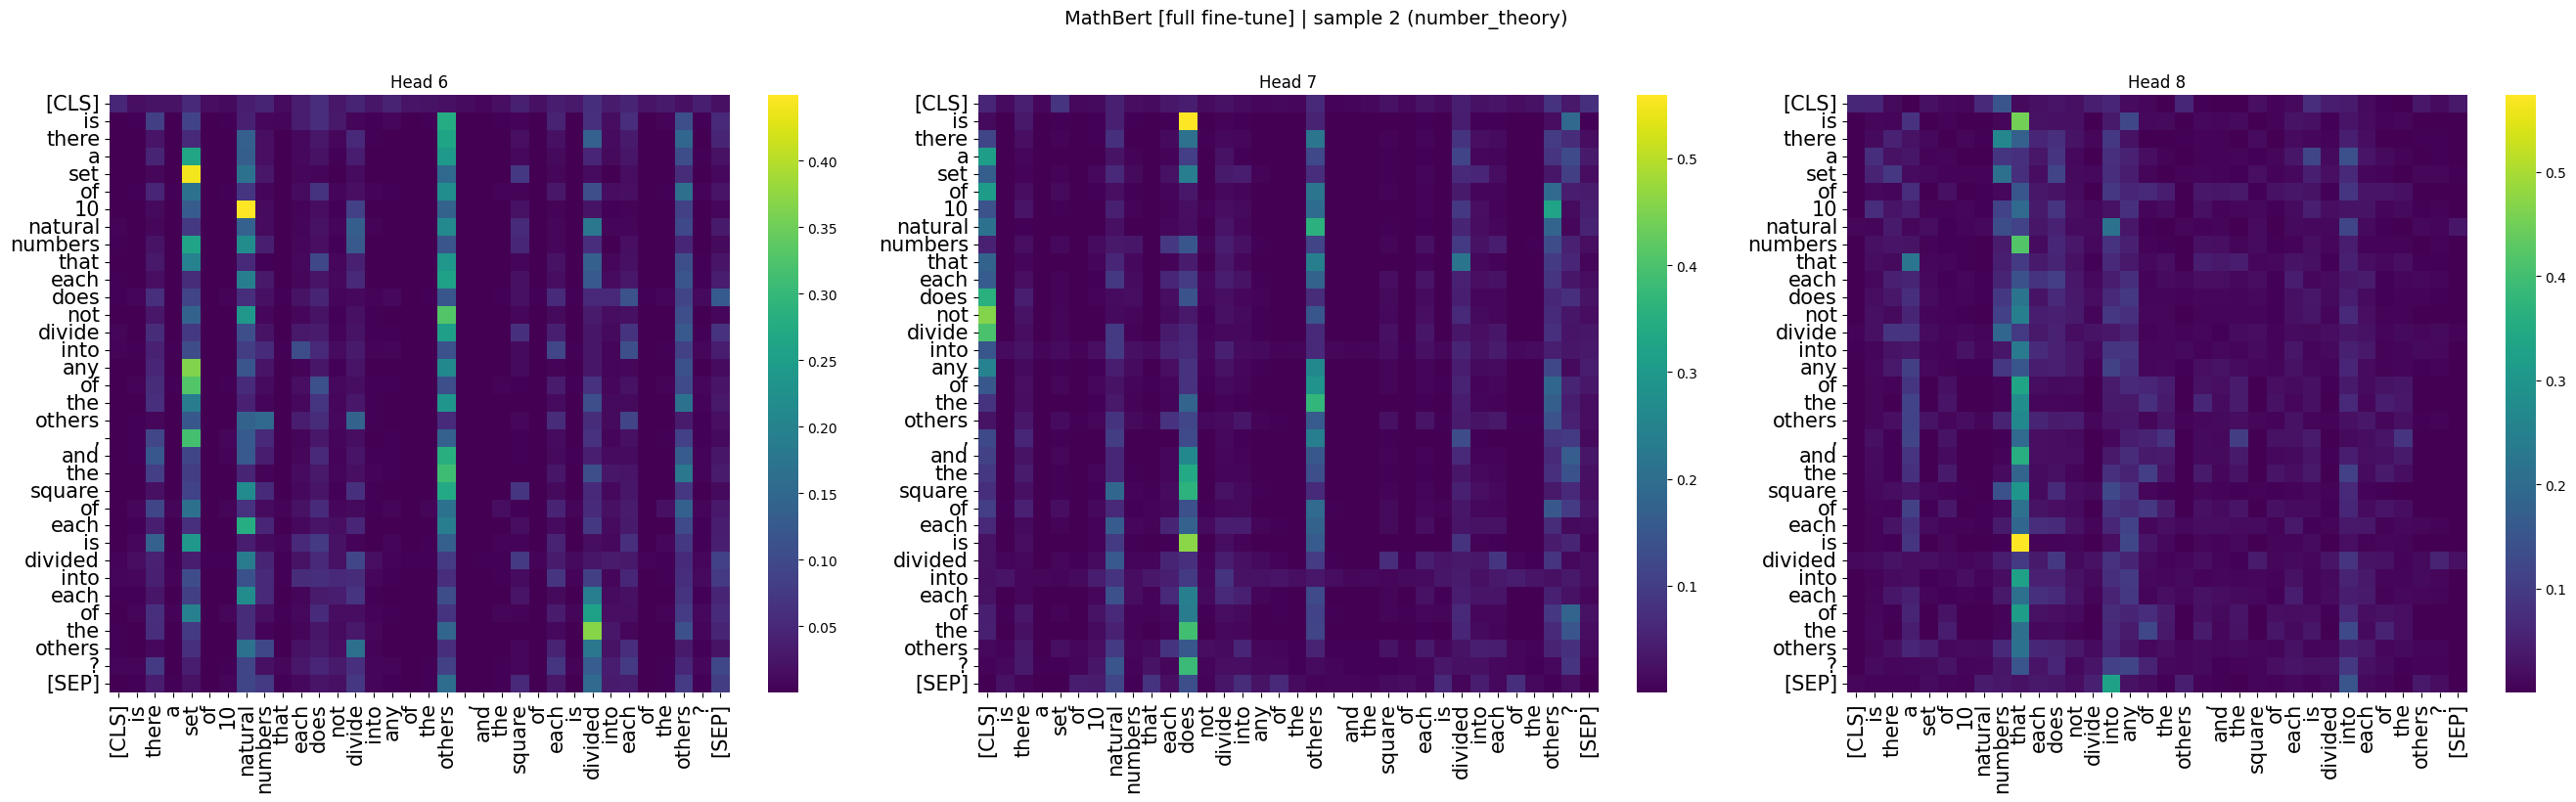

In [58]:
for i, sample in enumerate(test_samples):
    text = sample["problem_text"]
    topic = topics[sample["topic"]]
    tag = f"sample {i} ({topic})"
    draw_first_layer_attention_maps([0, 5, 9], text, rubert_tiny_finetuned_with_freezed_backbone, "cointegrated/rubert-tiny2",
                                    title=f"rubert-tiny2 [frozen backbone] | {tag}")
    draw_first_layer_attention_maps([0, 5, 9], text, rubert_tiny_full_finetuned,                  "cointegrated/rubert-tiny2",
                                    title=f"rubert-tiny2 [full fine-tune] | {tag}")
    draw_first_layer_attention_maps([6, 7, 8], text, mathbert_finetuned_with_freezed_backbone,    "tbs17/MathBert",
                                    title=f"MathBert [frozen backbone] | {tag}")
    draw_first_layer_attention_maps([6, 7, 8], text, mathbert_full_finetuned,                     "tbs17/MathBert",
                                    title=f"MathBert [full fine-tune] | {tag}")

In [49]:
display(test_samples["problem_text"])

Column(['Figure in natural numbers the equation nx + ny = nz.', 'The sequence {an} is defined by the rules: a0 = 9, prove that the decimal number of a10 contains at least 1,000 nine.', 'Is there a set of 10 natural numbers that each does not divide into any of the others, and the square of each is divided into each of the others?'])

## Вывод

MathBert показала себя лучше хотя бы потому что натренирована на английских текстах, полный файнтюн дал f1 скор на ~0.1 выше чем остальные модели

Касательно наблюдений за картами внимания заметно что, fully-fine-tuned модель стала меньше внимания обращать на бесполезные токены типа sep и . 

Голова 8 в первом предложении обращает больше внимания на + тогда как до файнтюна токен equation смотрел почти только на n (следующий токен)

В целом никаких других закономерностей обнаружено не было, веса меняются не радикально (по крайней мере, изменения не сильно видны на хитмапах) но в целом из закономерностей можно выделить меньшее внимание на бесполезные токены и в целом рассеяние внимания вместо концентрации его на одном токене

За руберт я не следил, почти все хитмапы диагональные что свидетельствует о том, что каждый токен почти всегда смотрит только на себя и на соседние токены -> нет понимания грамматической структуры, так как значимые слова не обязательно расположены рядом